#  Auto-Encodeur — Masquage de Pixels & Reconstruction
---

## Introduction & Contexte

Un **auto-encodeur** est un réseau de neurones non supervisé composé de deux parties :
- **L'encodeur** : compresse l'image d'entrée vers une représentation latente de dimension réduite (le *bottleneck*).
- **Le décodeur** : reconstruit l'image originale à partir de cette représentation compressée.

Dans ce notebook, nous explorons un cas plus difficile que le simple débruitage : le **masquage structuré de pixels**. Le modèle doit inférer les régions manquantes à partir du contexte environnant — une tâche proche de l'**inpainting** en vision par ordinateur.

### Pourquoi la reconstruction est-elle un problème de régression ?

> Contrairement à la classification qui prédit une classe discrète, la reconstruction d'image est un problème de **régression pixel-à-pixel**. Le modèle prédit l'intensité continue de chaque pixel (valeur dans [0, 1]), ce qui impose des métriques adaptées à cette nature continue.

### Originalité de ce projet

Ce projet entraîne **deux auto-encodeurs distincts** (σ=0.2 et σ=0.4) et évalue chacun sur **5 types de masquage**, permettant une étude comparative croisée complète :
- **Impact du niveau de bruit d'entraînement** sur la robustesse
- **Impact du type de masquage** sur la qualité de reconstruction

### Plan du notebook

| Section | Contenu |
|---------|--------|
| 1 | Imports & Configuration |
| 2 | Chargement des données |
| 3 | Bruit Gaussien — σ=0.2 et σ=0.4 |
| 4 | Architecture de l'Auto-Encodeur |
| 5 | Entraînement des 2 modèles |
| 6 | Méthodes de Masquage (5 stratégies) |
| **7** | **Évaluation Complète par Masquage × Sigma** |
| **8** | **Comparaison Croisée σ=0.2 vs σ=0.4** |
| 9 | Cartes d'erreur & Distribution |
| 10 | Synthèse Finale & Conclusion |

---
## 1. Imports & Configuration

In [1]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, losses
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model
from sklearn.metrics import mean_squared_error
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

tf.random.set_seed(42)
np.random.seed(42)

# ─── Constantes globales ────────────────────────────────────────────────────
SIGMAS       = [0.2, 0.4]
N_EVAL       = 200   # images pour l'évaluation des métriques (sur tout le test)
N_VIS        = 10    # images pour la visualisation
EPOCHS       = 10
BATCH_SIZE   = 128

PALETTE_DARK  = ['#E57373','#FF9800','#9C27B0','#2196F3','#F44336','#009688']
PALETTE_LIGHT = ['#FFCDD2','#FFE0B2','#E1BEE7','#BBDEFB','#EF9A9A','#B2DFDB']

print(f'   TensorFlow : {tf.__version__}')

   TensorFlow : 2.19.0


---
## 2. Chargement & Préparation des Données

Le dataset **Fashion-MNIST** contient 70 000 images en niveaux de gris (28×28 pixels).

| Split | Nombre d'images |
|-------|----------------|
| Entraînement | 60 000 |
| Test | 10 000 |

Les pixels sont normalisés dans l'intervalle [0, 1].

In [2]:
(x_train, _), (x_test, _) = fashion_mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test  = x_test.astype('float32')  / 255.

x_train = x_train[..., tf.newaxis]
x_test  = x_test[..., tf.newaxis]

print(f' Données chargées')
print(f'   x_train shape : {x_train.shape}')
print(f'   x_test  shape : {x_test.shape}')

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
 Données chargées
   x_train shape : (60000, 28, 28, 1)
   x_test  shape : (10000, 28, 28, 1)


---
## 3. Bruit Gaussien — σ = 0.2 et σ = 0.4

Nous créons deux versions bruitées du dataset pour entraîner deux modèles distincts :

$$x_{noisy} = x + \mathcal{N}(0, \sigma^2)$$

| Sigma | Intensité du bruit | Utilisation |
|-------|-------------------|-------------|
| σ = 0.2 | Faible | Modèle A — entraînement |
| σ = 0.4 | Fort | Modèle B — entraînement |

In [3]:
noisy_data = {}

for sigma in SIGMAS:
    x_tr_n = x_train + sigma * tf.random.normal(shape=x_train.shape)
    x_te_n = x_test  + sigma * tf.random.normal(shape=x_test.shape)
    noisy_data[sigma] = {
        'x_train_noisy': tf.clip_by_value(x_tr_n, 0., 1.),
        'x_test_noisy':  tf.clip_by_value(x_te_n, 0., 1.),
    }
    print(f' Bruit gaussien σ={sigma} — généré')

 Bruit gaussien σ=0.2 — généré
 Bruit gaussien σ=0.4 — généré


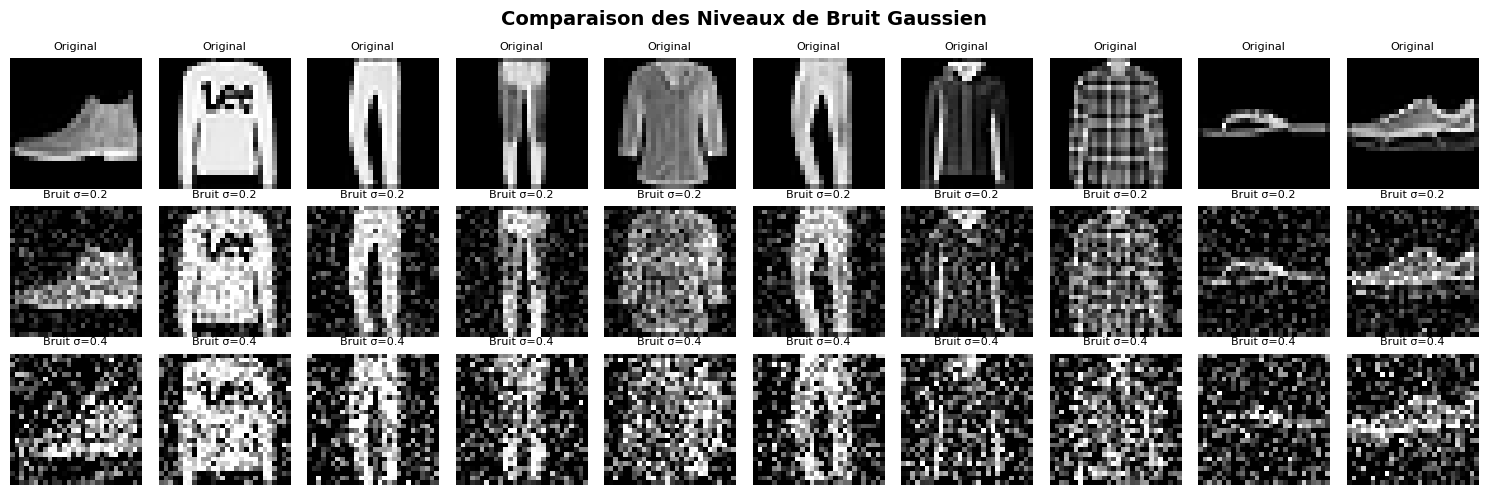

In [4]:
n = 10
fig, axes = plt.subplots(3, n, figsize=(15, 5))
fig.suptitle('Comparaison des Niveaux de Bruit Gaussien', fontsize=14, fontweight='bold')

row_labels = ['Original', 'Bruit σ=0.2', 'Bruit σ=0.4']
sources = [x_test, noisy_data[0.2]['x_test_noisy'], noisy_data[0.4]['x_test_noisy']]

for row, (lbl, src) in enumerate(zip(row_labels, sources)):
    for col in range(n):
        axes[row, col].imshow(np.squeeze(np.array(src[col])), cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')

        axes[row, col].set_title(lbl, fontsize=8)

plt.tight_layout()
plt.show()

---
## 4. Architecture de l'Auto-Encodeur Convolutif

### Pourquoi un Auto-Encodeur **Convolutif** ?

Les couches de convolution exploitent la **localité spatiale** des pixels. Contrairement à un MLP dense, le CNN partage ses poids et capture les motifs locaux (*translation invariance*), ce qui est crucial pour la reconstruction de régions masquées.

### Architecture détaillée

| Bloc | Opération | Filtres | Stride | Activation | Sortie |
|------|-----------|---------|--------|------------|--------|
| **Encodeur** | Conv2D | 32 | 2 | ReLU | 14×14×32 |
| **Encodeur** | Conv2D | 16 | 2 | ReLU | 7×7×16 |
| **Décodeur** | Conv2DTranspose | 16 | 2 | ReLU | 14×14×16 |
| **Décodeur** | Conv2DTranspose | 32 | 2 | ReLU | 28×28×32 |
| **Sortie** | Conv2D | 1 | 1 | Sigmoid | 28×28×1 |

> **Bottleneck** : 7×7×16 = 784 valeurs latentes — même dimension que l'image d'entrée (28×28=784), mais avec une représentation profondément encodée.

In [5]:
def build_autoencoder():
    class DenoisingAutoencoder(Model):
        def __init__(self):
            super(DenoisingAutoencoder, self).__init__()
            self.encoder = tf.keras.Sequential([
                layers.Input(shape=(28, 28, 1)),
                layers.Conv2D(32, (3,3), activation='relu', padding='same', strides=2),
                layers.Conv2D(16, (3,3), activation='relu', padding='same', strides=2),
            ], name='encoder')
            self.decoder = tf.keras.Sequential([
                layers.Conv2DTranspose(16, kernel_size=3, strides=2, activation='relu', padding='same'),
                layers.Conv2DTranspose(32, kernel_size=3, strides=2, activation='relu', padding='same'),
                layers.Conv2D(1, kernel_size=(3,3), activation='sigmoid', padding='same'),
            ], name='decoder')

        def call(self, x):
            return self.decoder(self.encoder(x))

    ae = DenoisingAutoencoder()
    ae.compile(optimizer='adam', loss=losses.BinaryCrossentropy())
    return ae

demo_model = build_autoencoder()
demo_model.encoder.summary()
demo_model.decoder.summary()
del demo_model
print('\n Architecture définie')

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 16)       │         4,624 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,944 (19.31 KB)

 Trainable params: 4,944 (19.31 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_transpose                │ ?                      │   0 (unbuilt) │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ ?                      │   0 (unbuilt) │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


 Architecture définie


---
## 5. Entraînement des Deux Modèles

Deux auto-encodeurs sont entraînés indépendamment :
- **Modèle A** : entraîné sur données bruitées avec σ=0.2
- **Modèle B** : entraîné sur données bruitées avec σ=0.4

Chaque modèle apprend à reconstruire l'image propre depuis sa version bruitée respective.

In [6]:
models    = {}
histories = {}

for sigma in SIGMAS:
    print(f'\n{'='*60}')
    print(f'  Entraînement du modèle σ = {sigma}')
    print(f'{'='*60}')

    ae = build_autoencoder()
    hist = ae.fit(
        noisy_data[sigma]['x_train_noisy'], x_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=True,
        validation_data=(noisy_data[sigma]['x_test_noisy'], x_test),
        verbose=1
    )
    models[sigma]    = ae
    histories[sigma] = hist
    print(f'\n Modèle σ={sigma} entraîné !')

print('\n Les 2 modèles sont prêts !')


  Entraînement du modèle σ = 0.2
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 173ms/step - loss: 0.3321 - val_loss: 0.2879
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 171ms/step - loss: 0.2821 - val_loss: 0.2807
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 78s 165ms/step - loss: 0.2771 - val_loss: 0.2775
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 163ms/step - loss: 0.2744 - val_loss: 0.2752
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 80s 171ms/step - loss: 0.2727 - val_loss: 0.2739
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 174ms/step - loss: 0.2715 - val_loss: 0.2730
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 78s 165ms/step - loss: 0.2706 - val_loss: 0.2722
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 173ms/step - loss: 0.2700 - val_loss: 0.2716
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 80s 170ms/step - loss: 0.2695 - val_loss: 0.2711
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 178ms/step - loss: 0.2691 - val_loss: 0.2708

 Modèle σ=0.2 entraîné !

  Entraînement du modèle σ = 0.4
Epoch 1/10
469/

### 5.1 — Courbes de perte — comparaison σ=0.2 vs σ=0.4

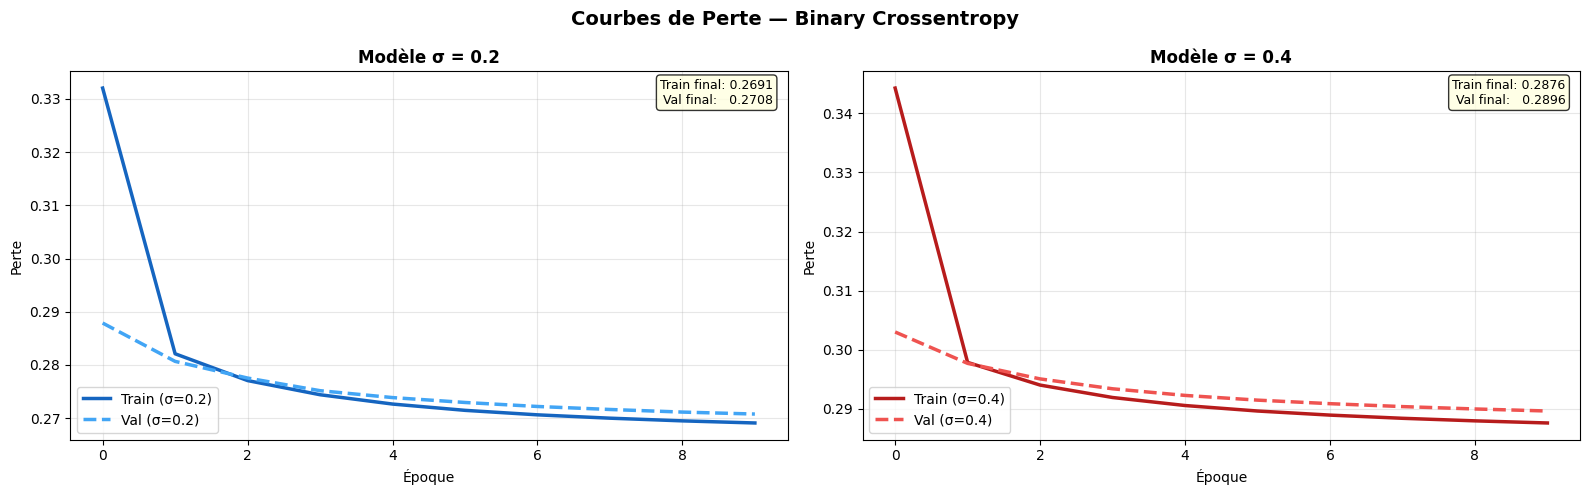

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Courbes de Perte — Binary Crossentropy', fontsize=14, fontweight='bold')

colors = {0.2: ('#1565C0', '#42A5F5'), 0.4: ('#B71C1C', '#EF5350')}

for ax, sigma in zip(axes, SIGMAS):
    c_train, c_val = colors[sigma]
    hist = histories[sigma]
    ax.plot(hist.history['loss'],     color=c_train, lw=2.5, label=f'Train (σ={sigma})')
    ax.plot(hist.history['val_loss'], color=c_val,   lw=2.5, linestyle='--', label=f'Val (σ={sigma})')
    ax.set_title(f'Modèle σ = {sigma}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Époque'); ax.set_ylabel('Perte')
    ax.legend(fontsize=10); ax.grid(alpha=0.3)
    final_train = hist.history['loss'][-1]
    final_val   = hist.history['val_loss'][-1]
    ax.text(0.98, 0.98, f'Train final: {final_train:.4f}\nVal final:   {final_val:.4f}',
            transform=ax.transAxes, va='top', ha='right', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

---
## 6. Méthodes de Masquage de Pixels

Le **masquage de pixels** est une technique de corruption structurée. Nous comparons **5 stratégies** :

| # | Méthode | Pixels masqués |
|---|---------|---------------|
| 1 | **Aléatoire** | ~50% dispersé |
| 2 | **Par Lignes** | ~50% structuré horiz. |
| 3 | **Par Colonnes** | ~50% structuré vert. |
| 4 | **Patch carré** | ~25% central |
| 5 | **Quadrant** | ~25% asymétrique |

### -> Fonctions de masquage

In [8]:
def mask_random(images, mask_ratio=0.5, seed=42):
    """Masquage aléatoire uniforme — mask_ratio% des pixels mis à 0."""
    np.random.seed(seed)
    imgs = np.array(images).copy()
    mask = np.random.rand(*imgs.shape) > mask_ratio
    return (imgs * mask).astype('float32')

In [9]:
def mask_rows(images, step=2):
    """Masquage par lignes — 1 ligne sur step mise à 0."""
    imgs = np.array(images).copy()
    imgs[:, ::step, :, :] = 0.
    return imgs.astype('float32')

In [10]:
def mask_cols(images, step=2):
    """Masquage par colonnes — 1 colonne sur step mise à 0."""
    imgs = np.array(images).copy()
    imgs[:, :, ::step, :] = 0.
    return imgs.astype('float32')

In [11]:
def mask_patch(images, patch_size=14):
    """Masquage patch carré central."""
    imgs = np.array(images).copy()
    H, W = imgs.shape[1], imgs.shape[2]
    r0 = (H - patch_size) // 2
    c0 = (W - patch_size) // 2
    imgs[:, r0:r0+patch_size, c0:c0+patch_size, :] = 0.
    return imgs.astype('float32')

In [12]:
def mask_quadrant(images, quadrant='bottom_right'):
    """Masquage quadrant — 1/4 de l'image mis à 0."""
    imgs = np.array(images).copy()
    H, W = imgs.shape[1], imgs.shape[2]
    hH, hW = H // 2, W // 2
    if quadrant == 'bottom_right': imgs[:, hH:, hW:, :] = 0.
    elif quadrant == 'top_left':   imgs[:, :hH, :hW, :] = 0.
    elif quadrant == 'top_right':  imgs[:, :hH, hW:, :] = 0.
    elif quadrant == 'bottom_left':imgs[:, hH:, :hW, :] = 0.
    return imgs.astype('float32')

### -> Application des masquages

In [13]:
MASKING_FUNCS = {
    'Aléatoire':   lambda imgs: mask_random(imgs),
    'Lignes':      lambda imgs: mask_rows(imgs),
    'Colonnes':    lambda imgs: mask_cols(imgs),
    'Patch carré': lambda imgs: mask_patch(imgs),
    'Quadrant':    lambda imgs: mask_quadrant(imgs),
}

masked_test  = {name: fn(x_test)  for name, fn in MASKING_FUNCS.items()}
masked_train = {name: fn(x_train) for name, fn in MASKING_FUNCS.items()}

print(' Tous les masquages appliqués :')
for name in masked_test:
    print(f'   {name:15s} → shape: {masked_test[name].shape}')

 Tous les masquages appliqués :
   Aléatoire       → shape: (10000, 28, 28, 1)
   Lignes          → shape: (10000, 28, 28, 1)
   Colonnes        → shape: (10000, 28, 28, 1)
   Patch carré     → shape: (10000, 28, 28, 1)
   Quadrant        → shape: (10000, 28, 28, 1)


### 6.1 — Visualisation comparative des 5 masquages

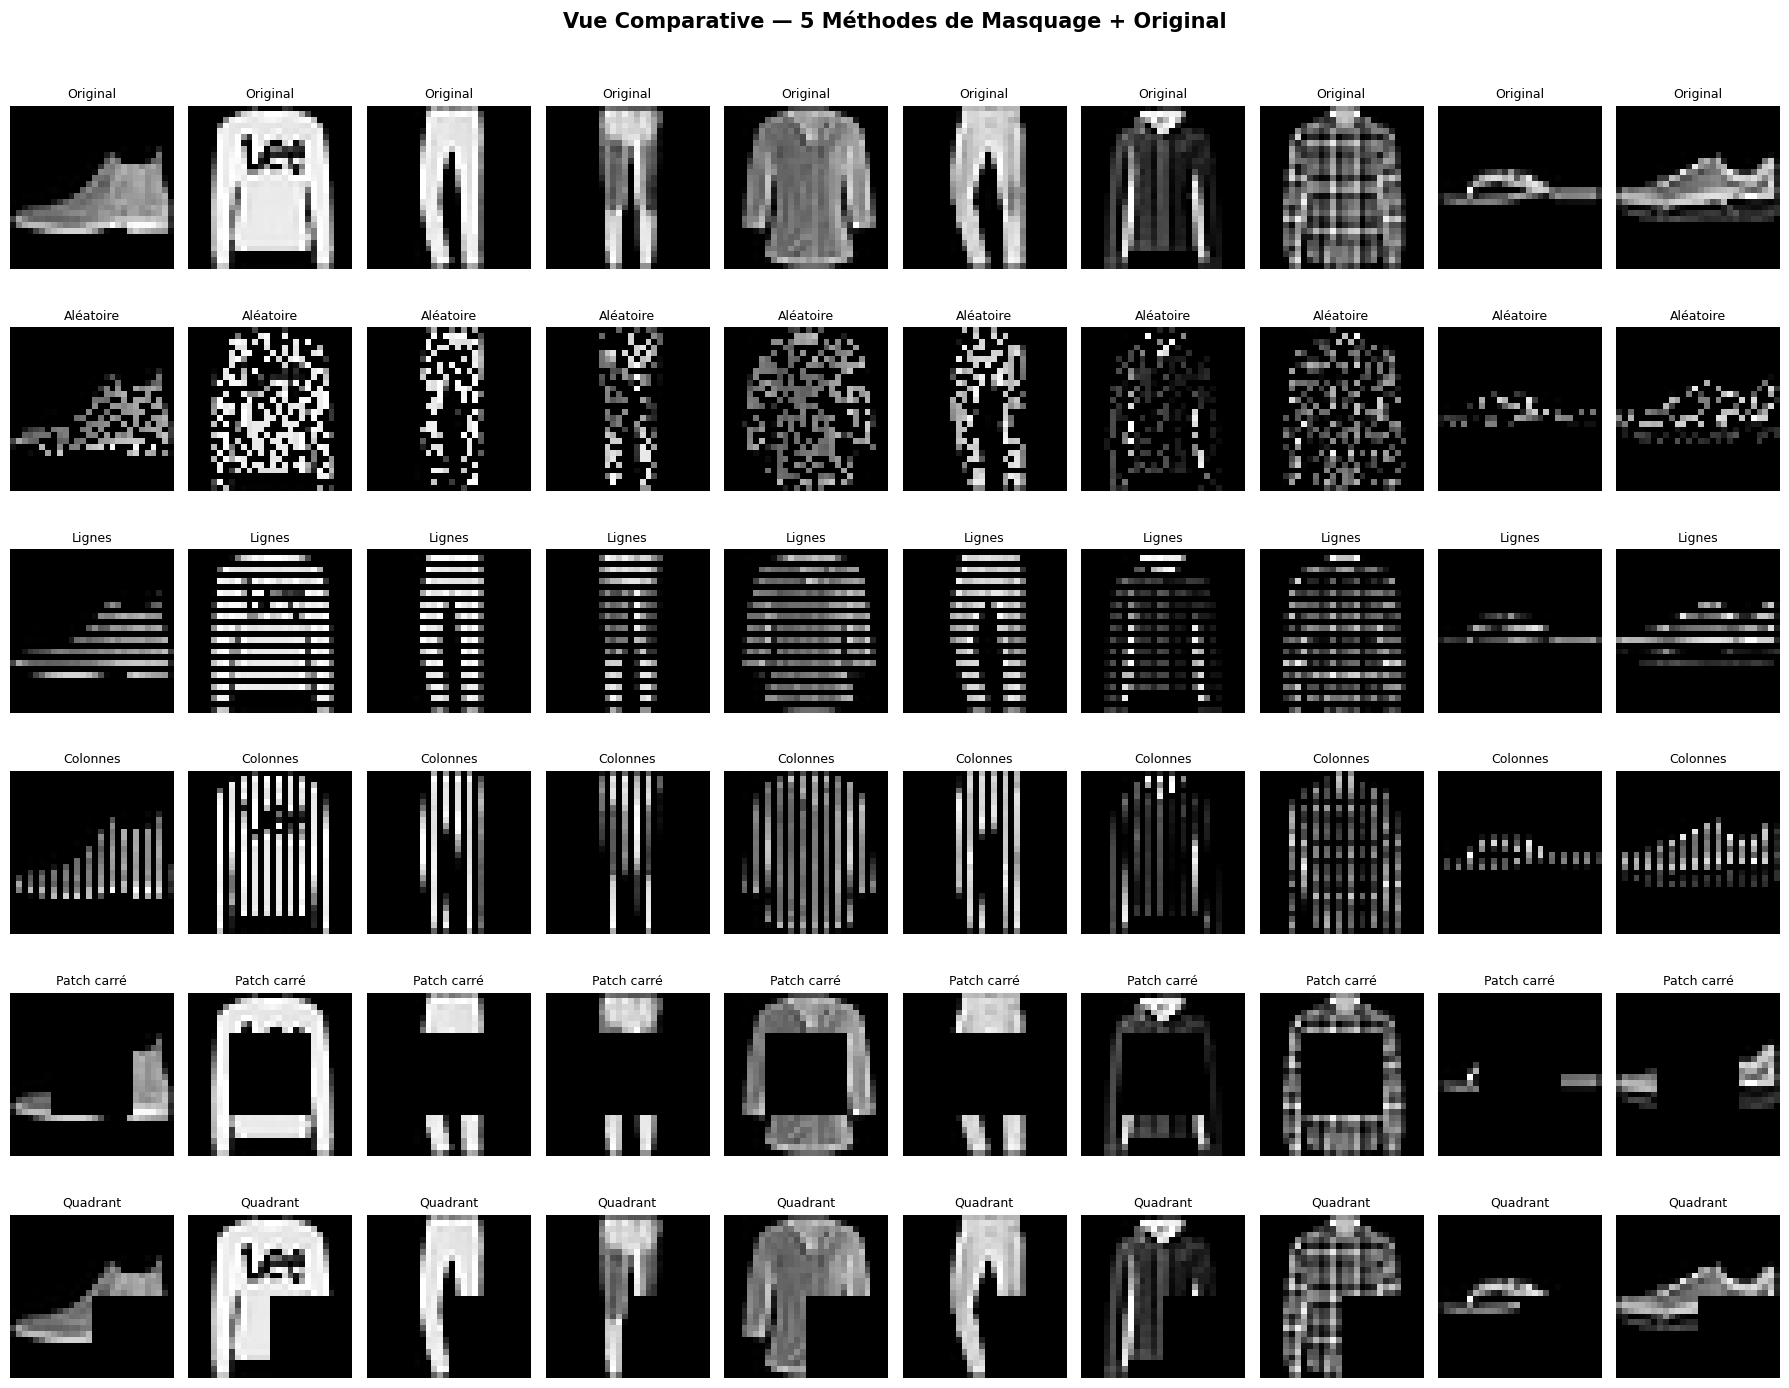


 Tableau récapitulatif des méthodes de masquage :


,Méthode,Pixels masqués (%),Structure,Difficulté,Type de défi
0,Aléatoire,50,Non structuré,⭐⭐,Interpolation locale
1,Lignes,50,H. régulier,⭐⭐⭐,Interpolation vert.
2,Colonnes,50,V. régulier,⭐⭐⭐,Interpolation horiz.
3,Patch carré,25,Contiguë centrée,⭐⭐⭐⭐,Inpainting central
4,Quadrant,25,Contiguë asymétrique,⭐⭐⭐⭐⭐,Extrapolation spatiale


In [14]:
n_imgs = 10
all_rows = [('Original', x_test)] + [(name, masked_test[name]) for name in MASKING_FUNCS]

fig, axes = plt.subplots(len(all_rows), n_imgs, figsize=(18, 14))
fig.suptitle('Vue Comparative — 5 Méthodes de Masquage + Original',
             fontsize=15, fontweight='bold', y=1.01)

for row, (label, src) in enumerate(all_rows):
    for col in range(n_imgs):
        ax = axes[row, col]
        ax.imshow(np.squeeze(np.array(src[col])), cmap='gray', vmin=0, vmax=1)
        ax.axis('off')

        ax.set_title(label, fontsize=9)

    if n_imgs > 0:
        axes[row, 0].set_ylabel(label, fontsize=10, rotation=0,
                                labelpad=120, va='center',
                                fontweight='bold' if row == 0 else 'normal')

plt.tight_layout()
plt.show()

# Tableau récapitulatif
mask_summary = pd.DataFrame({
    'Méthode': list(MASKING_FUNCS.keys()),
    'Pixels masqués (%)': [50, 50, 50, 25, 25],
    'Structure': ['Non structuré', 'H. régulier', 'V. régulier', 'Contiguë centrée', 'Contiguë asymétrique'],
    'Difficulté': ['⭐⭐', '⭐⭐⭐', '⭐⭐⭐', '⭐⭐⭐⭐', '⭐⭐⭐⭐⭐'],
    'Type de défi': ['Interpolation locale', 'Interpolation vert.', 'Interpolation horiz.', 'Inpainting central', 'Extrapolation spatiale'],
})

print('\n Tableau récapitulatif des méthodes de masquage :')
display(mask_summary.style
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([{'selector': 'th', 'props': [('font-weight','bold'),('font-size','12px')]}])
    .set_caption(' Comparaison des 5 Stratégies de Masquage')
)

---
## 7. Reconstruction par Chaque Modèle sur Chaque Masquage

### 7.1 Masquage par Bruit gaussien

In [15]:
decoded = {}

for sigma in SIGMAS:
    decoded[sigma] = {}
    # Bruit Gaussien uniquement
    decoded[sigma]['Bruit Gaussien'] = models[sigma].predict(
        noisy_data[sigma]['x_test_noisy'], verbose=0)
    print(f' Reconstructions σ={sigma} terminées')

print('\n Toutes les reconstructions terminées !')
print(f'   Conditions : {list(decoded[0.2].keys())}')

 Reconstructions σ=0.2 terminées
 Reconstructions σ=0.4 terminées

 Toutes les reconstructions terminées !
   Conditions : ['Bruit Gaussien']


### 7.2 Autres types de masquage

In [16]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [17]:
# ─── Définition de la fonction de création du modèle ──────────────────────────
def build_autoencoder(input_shape):
    input_img = Input(shape=input_shape)
    x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2,2), padding='same')(x)
    x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2,2), padding='same')(x)
    x = Conv2D(64, (3,3), activation='relu', padding='same')(encoded)
    x = UpSampling2D((2,2))(x)
    x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
    x = UpSampling2D((2,2))(x)
    output = Conv2D(input_shape[-1], (3,3), activation='sigmoid', padding='same')(x)
    model = Model(input_img, output)
    model.compile(optimizer='adam', loss='mse')
    return model

history_clean = {}
models_clean  = {}

### **Masquage Aléatoire**

In [18]:
mname = 'Aléatoire'
models_clean[mname] = build_autoencoder(x_train.shape[1:])
history_clean[mname] = models_clean[mname].fit(
    masked_train[mname], x_train,
    epochs=10, batch_size=128, shuffle=True,
    validation_data=(masked_test[mname], x_test),
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True),
               ReduceLROnPlateau(patience=3, factor=0.5)], verbose=1)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 173s 362ms/step - loss: 0.0227 - val_loss: 0.0156 - learning_rate: 0.0010
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 157s 335ms/step - loss: 0.0143 - val_loss: 0.0137 - learning_rate: 0.0010
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 202s 335ms/step - loss: 0.0130 - val_loss: 0.0127 - learning_rate: 0.0010
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 157s 335ms/step - loss: 0.0122 - val_loss: 0.0121 - learning_rate: 0.0010
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 157s 335ms/step - loss: 0.0115 - val_loss: 0.0112 - learning_rate: 0.0010
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 206s 344ms/step - loss: 0.0108 - val_loss: 0.0106 - learning_rate: 0.0010
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 200s 339ms/step - loss: 0.0103 - val_loss: 0.0104 - learning_rate: 0.0010
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 201s 338ms/step - loss: 0.0099 - val_loss: 0.0098 - learning_rate: 0.0010
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 162s 345ms/step - loss: 0.0096 - val_loss: 0.009

### **Masquage par lignes**

In [19]:
mname = 'Lignes'
models_clean[mname] = build_autoencoder(x_train.shape[1:])
history_clean[mname] = models_clean[mname].fit(
    masked_train[mname], x_train,
    epochs=10, batch_size=128, shuffle=True,
    validation_data=(masked_test[mname], x_test),
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True),
               ReduceLROnPlateau(patience=3, factor=0.5)], verbose=1)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 165s 345ms/step - loss: 0.0197 - val_loss: 0.0122 - learning_rate: 0.0010
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 161s 344ms/step - loss: 0.0108 - val_loss: 0.0100 - learning_rate: 0.0010
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 158s 337ms/step - loss: 0.0091 - val_loss: 0.0083 - learning_rate: 0.0010
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 200s 334ms/step - loss: 0.0079 - val_loss: 0.0075 - learning_rate: 0.0010
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 206s 341ms/step - loss: 0.0073 - val_loss: 0.0070 - learning_rate: 0.0010
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 159s 339ms/step - loss: 0.0069 - val_loss: 0.0067 - learning_rate: 0.0010
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 158s 337ms/step - loss: 0.0067 - val_loss: 0.0065 - learning_rate: 0.0010
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 207s 348ms/step - loss: 0.0064 - val_loss: 0.0063 - learning_rate: 0.0010
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 155s 330ms/step - loss: 0.0063 - val_loss: 0.006

### **Masquage par colonnes**

In [20]:
mname = 'Colonnes'
models_clean[mname] = build_autoencoder(x_train.shape[1:])
history_clean[mname] = models_clean[mname].fit(
    masked_train[mname], x_train,
    epochs=10, batch_size=256, shuffle=True,
    validation_data=(masked_test[mname], x_test),
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True),
               ReduceLROnPlateau(patience=3, factor=0.5)], verbose=1)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 171s 721ms/step - loss: 0.0274 - val_loss: 0.0150 - learning_rate: 0.0010
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 194s 687ms/step - loss: 0.0135 - val_loss: 0.0124 - learning_rate: 0.0010
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 163s 694ms/step - loss: 0.0118 - val_loss: 0.0112 - learning_rate: 0.0010
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 155s 658ms/step - loss: 0.0108 - val_loss: 0.0105 - learning_rate: 0.0010
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 207s 681ms/step - loss: 0.0101 - val_loss: 0.0098 - learning_rate: 0.0010
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 157s 667ms/step - loss: 0.0094 - val_loss: 0.0091 - learning_rate: 0.0010
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 158s 674ms/step - loss: 0.0089 - val_loss: 0.0088 - learning_rate: 0.0010
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 204s 683ms/step - loss: 0.0085 - val_loss: 0.0084 - learning_rate: 0.0010
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 157s 669ms/step - loss: 0.0082 - val_loss: 0.008

### **Masquage par Patch carré**

In [21]:
mname = 'Patch carré'
models_clean[mname] = build_autoencoder(x_train.shape[1:])
history_clean[mname] = models_clean[mname].fit(
    masked_train[mname], x_train,
    epochs=10, batch_size=128, shuffle=True,
    validation_data=(masked_test[mname], x_test),
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True),
               ReduceLROnPlateau(patience=3, factor=0.5)], verbose=1)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 166s 350ms/step - loss: 0.0254 - val_loss: 0.0158 - learning_rate: 0.0010
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 159s 339ms/step - loss: 0.0147 - val_loss: 0.0135 - learning_rate: 0.0010
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 201s 337ms/step - loss: 0.0129 - val_loss: 0.0123 - learning_rate: 0.0010
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 203s 338ms/step - loss: 0.0118 - val_loss: 0.0113 - learning_rate: 0.0010
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 161s 343ms/step - loss: 0.0110 - val_loss: 0.0106 - learning_rate: 0.0010
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 157s 336ms/step - loss: 0.0104 - val_loss: 0.0101 - learning_rate: 0.0010
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 204s 339ms/step - loss: 0.0100 - val_loss: 0.0099 - learning_rate: 0.0010
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 158s 337ms/step - loss: 0.0096 - val_loss: 0.0094 - learning_rate: 0.0010
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 156s 332ms/step - loss: 0.0094 - val_loss: 0.009

### **Masquage par Quadrant**

In [23]:
mname = 'Quadrant'
models_clean[mname] = build_autoencoder(x_train.shape[1:])
history_clean[mname] = models_clean[mname].fit(
    masked_train[mname], x_train,
    epochs=10, batch_size=128, shuffle=True,
    validation_data=(masked_test[mname], x_test),
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True),
               ReduceLROnPlateau(patience=3, factor=0.5)], verbose=1)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 166s 348ms/step - loss: 0.0255 - val_loss: 0.0164 - learning_rate: 0.0010
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 163s 347ms/step - loss: 0.0152 - val_loss: 0.0139 - learning_rate: 0.0010
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 196s 333ms/step - loss: 0.0132 - val_loss: 0.0125 - learning_rate: 0.0010
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 162s 345ms/step - loss: 0.0119 - val_loss: 0.0114 - learning_rate: 0.0010
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 202s 344ms/step - loss: 0.0110 - val_loss: 0.0107 - learning_rate: 0.0010
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 197s 334ms/step - loss: 0.0104 - val_loss: 0.0102 - learning_rate: 0.0010
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 206s 343ms/step - loss: 0.0099 - val_loss: 0.0098 - learning_rate: 0.0010
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 160s 342ms/step - loss: 0.0096 - val_loss: 0.0096 - learning_rate: 0.0010
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 197s 332ms/step - loss: 0.0093 - val_loss: 0.009

---
## 7A — Évaluation Visuelle par Masquage × Sigma

Pour chaque méthode de masquage, on affiche côte à côte les reconstructions des **deux modèles** (σ=0.2 et σ=0.4) afin d'observer visuellement l'impact du niveau d'entraînement.

---
## 7B — Évaluation MSE par Masquage × Sigma

Pour chaque masquage, on calcule la MSE sur les `N_VIS` premières images de test et on compare :
- MSE Masqué (corruption initiale)
- MSE Reconstruit σ=0.2
- MSE Reconstruit σ=0.4

In [24]:
decoded_clean = {}
for mname in MASKING_FUNCS:
    decoded_clean[mname] = models_clean[mname].predict(masked_test[mname], verbose=0)
    print(f' {mname} → shape: {decoded_clean[mname].shape}')

 Aléatoire → shape: (10000, 28, 28, 1)
 Lignes → shape: (10000, 28, 28, 1)
 Colonnes → shape: (10000, 28, 28, 1)
 Patch carré → shape: (10000, 28, 28, 1)
 Quadrant → shape: (10000, 28, 28, 1)


**1. Gaussien σ=0.2**

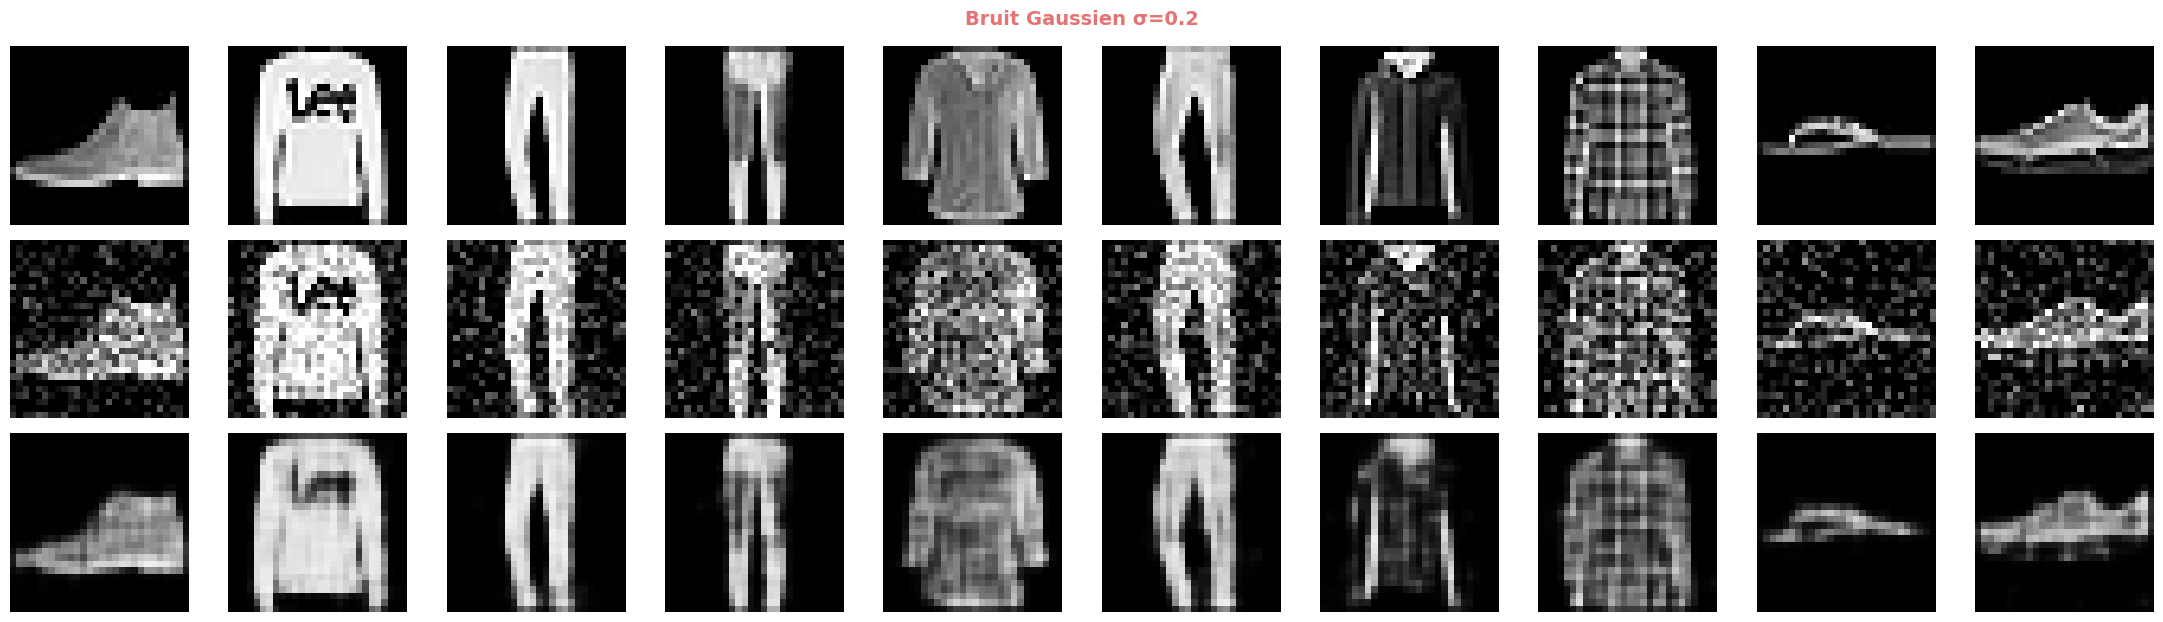

In [25]:
fig, axes = plt.subplots(3, N_VIS, figsize=(22, 3 * 2.1))
fig.suptitle('Bruit Gaussien σ=0.2', fontsize=14, fontweight='bold', color='#E57373')
for row, (lbl, src) in enumerate([
    ('Original',      x_test),
    ('Bruité σ=0.2',  noisy_data[0.2]['x_test_noisy']),
    ('Reconstruit',   decoded[0.2]['Bruit Gaussien']),
]):
    for col in range(N_VIS):
        axes[row, col].imshow(np.squeeze(np.array(src[col])), cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(lbl, fontsize=9, rotation=0, labelpad=80, va='center')
plt.tight_layout()
plt.show()

**2. Gaussien σ=0.4**

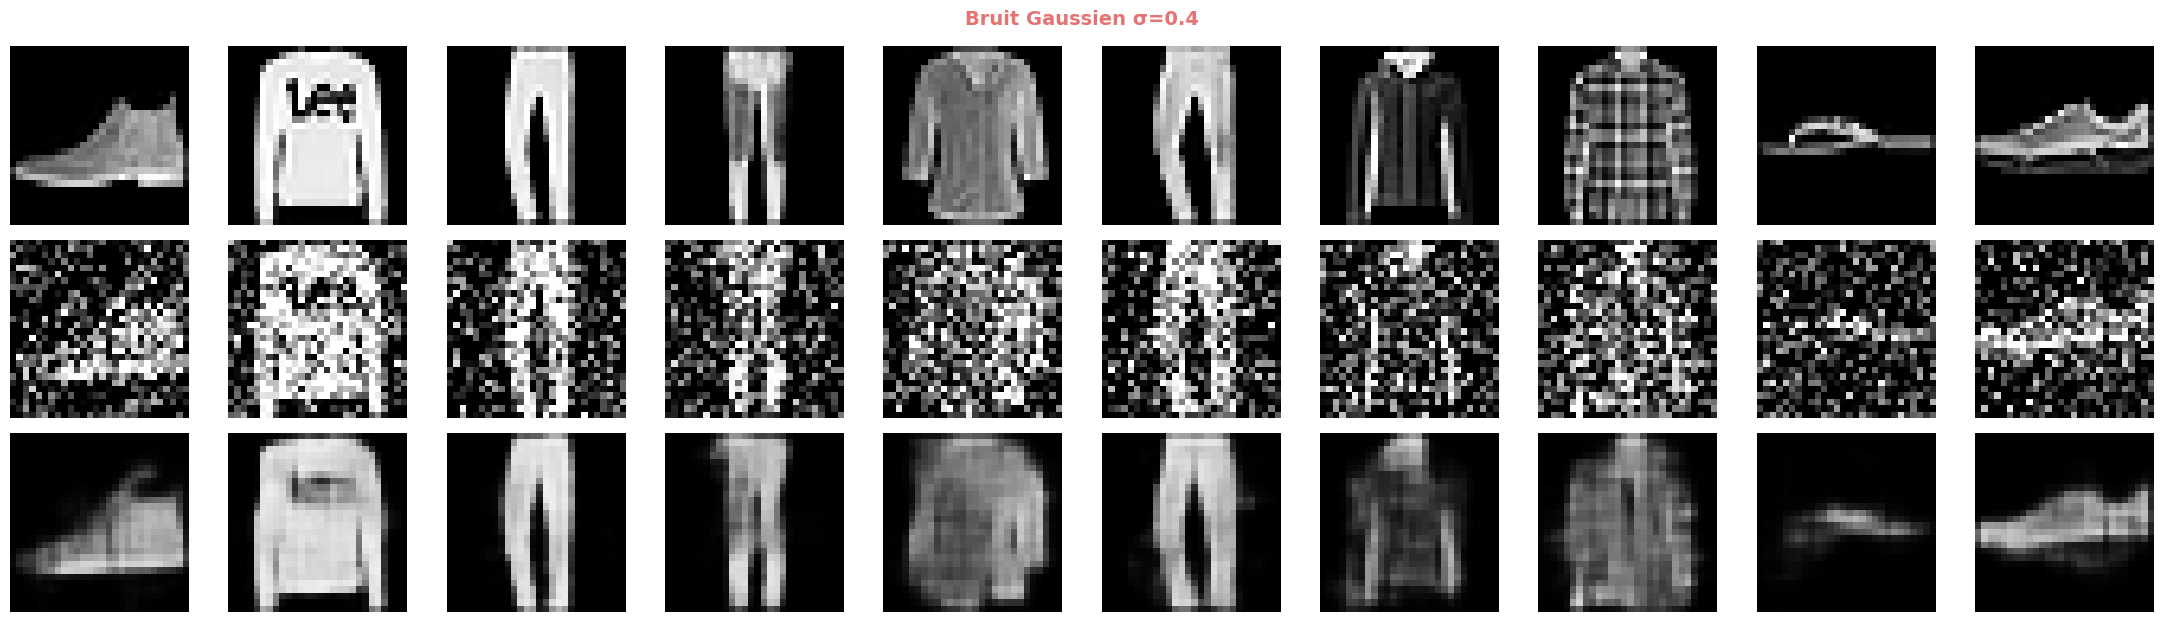

In [26]:
fig, axes = plt.subplots(3, N_VIS, figsize=(22, 3 * 2.1))
fig.suptitle('Bruit Gaussien σ=0.4', fontsize=14, fontweight='bold', color='#E57373')
for row, (lbl, src) in enumerate([
    ('Original',      x_test),
    ('Bruité σ=0.4',  noisy_data[0.4]['x_test_noisy']),
    ('Reconstruit',   decoded[0.4]['Bruit Gaussien']),
]):
    for col in range(N_VIS):
        axes[row, col].imshow(np.squeeze(np.array(src[col])), cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(lbl, fontsize=9, rotation=0, labelpad=80, va='center')
plt.tight_layout()
plt.show()

**3. Masquages (modèles_clean)**

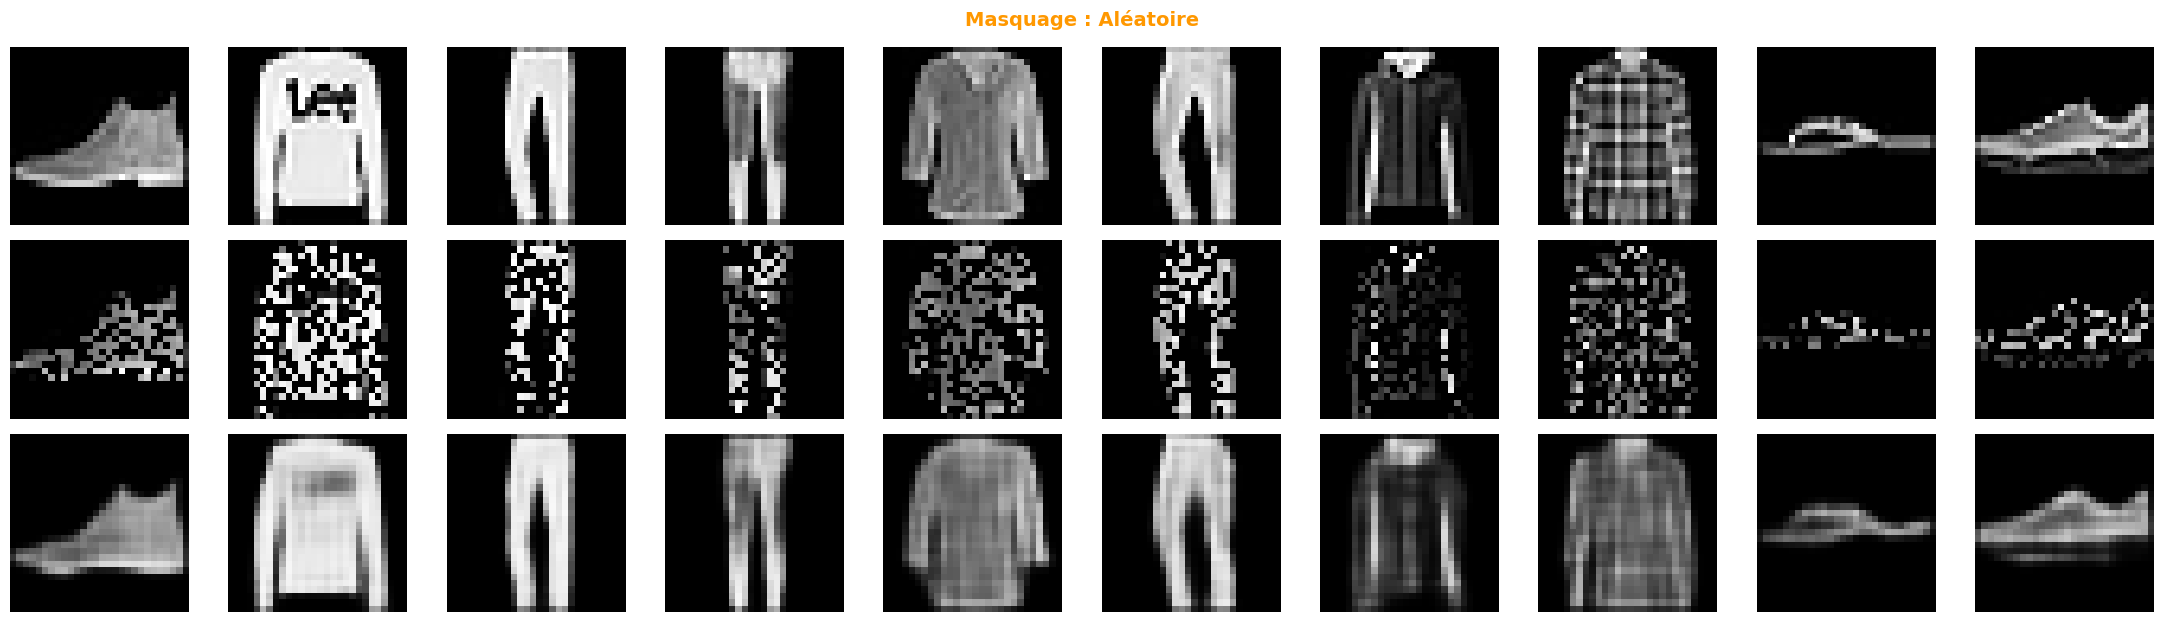

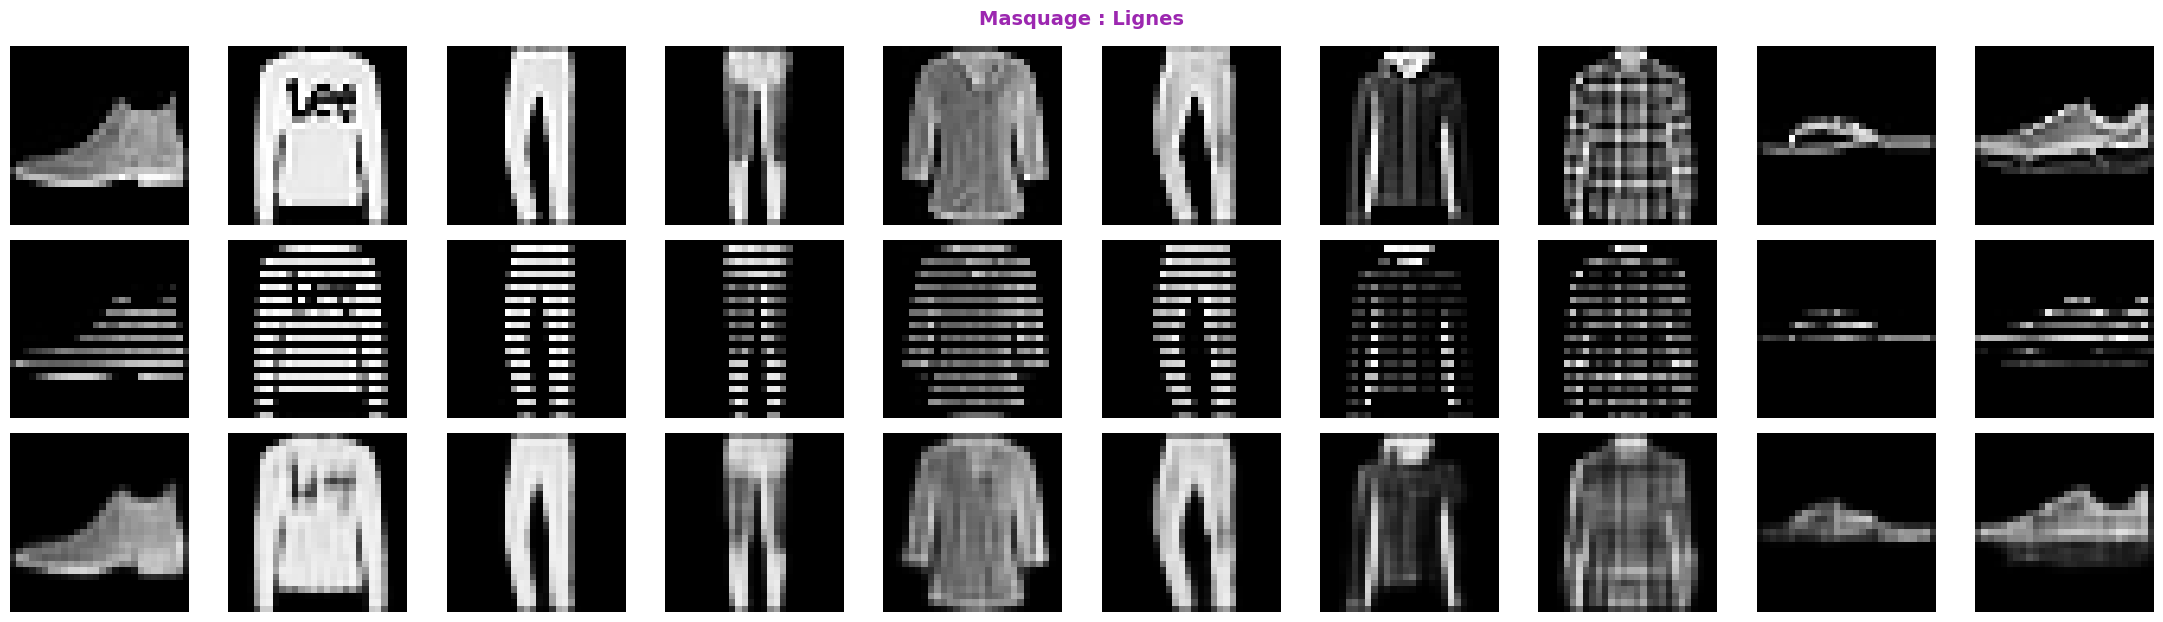

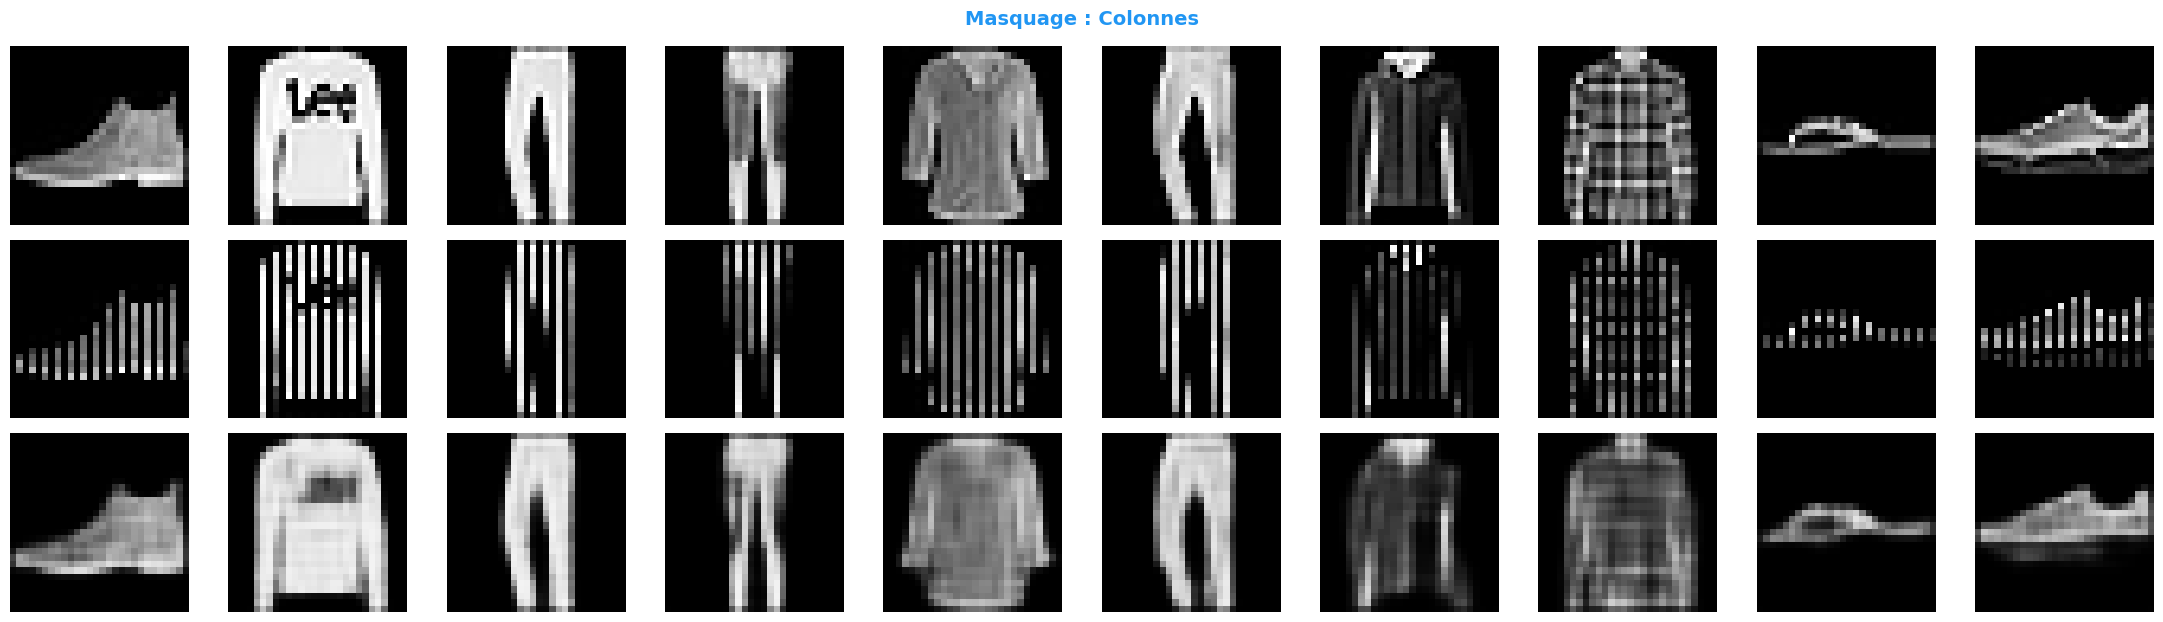

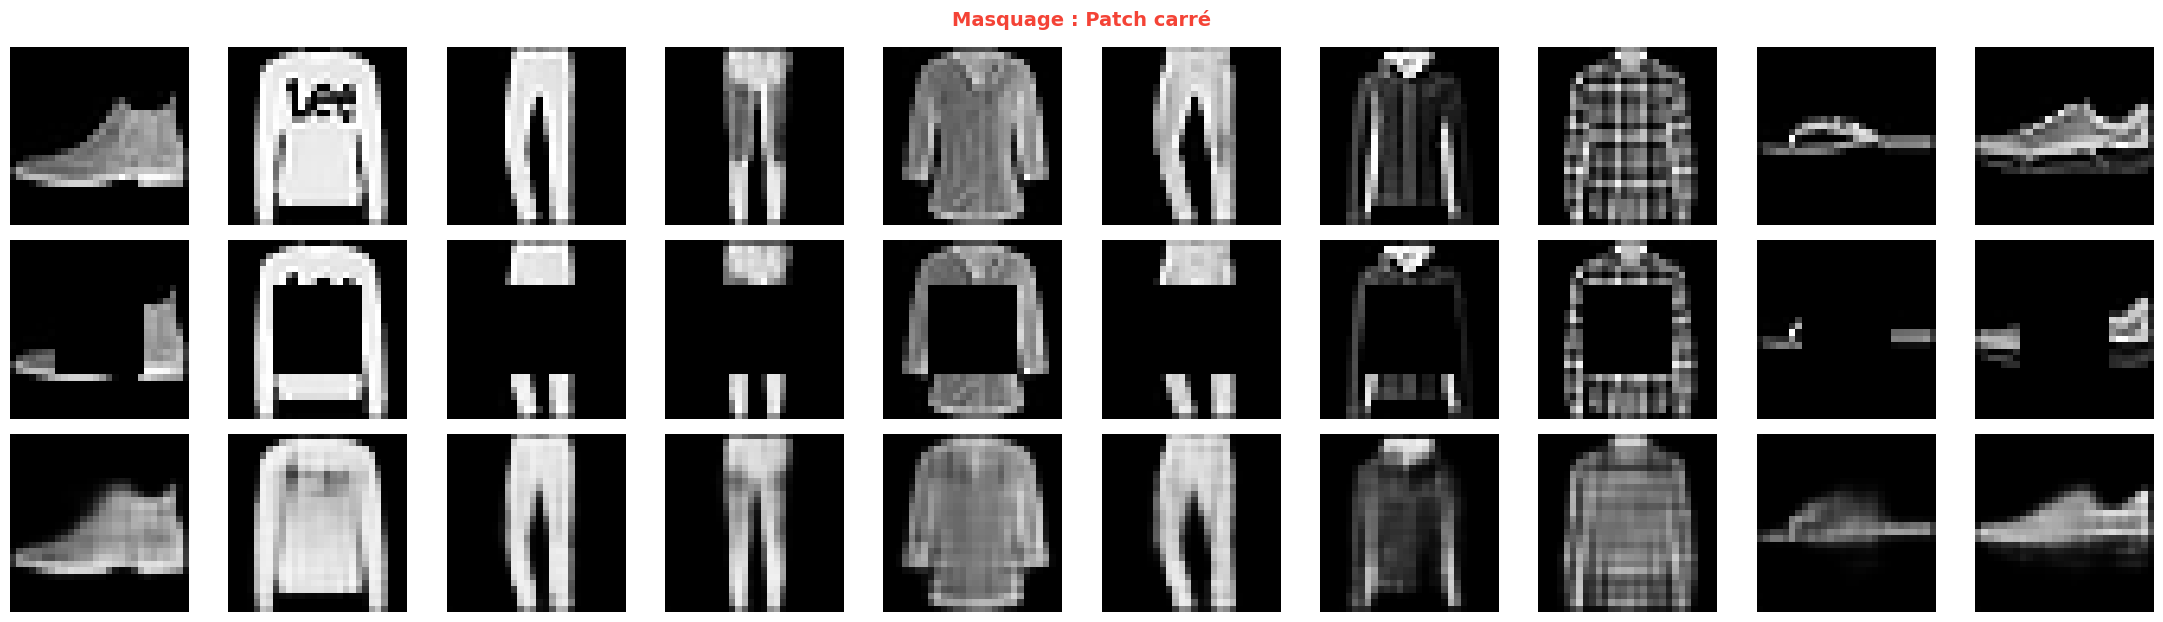

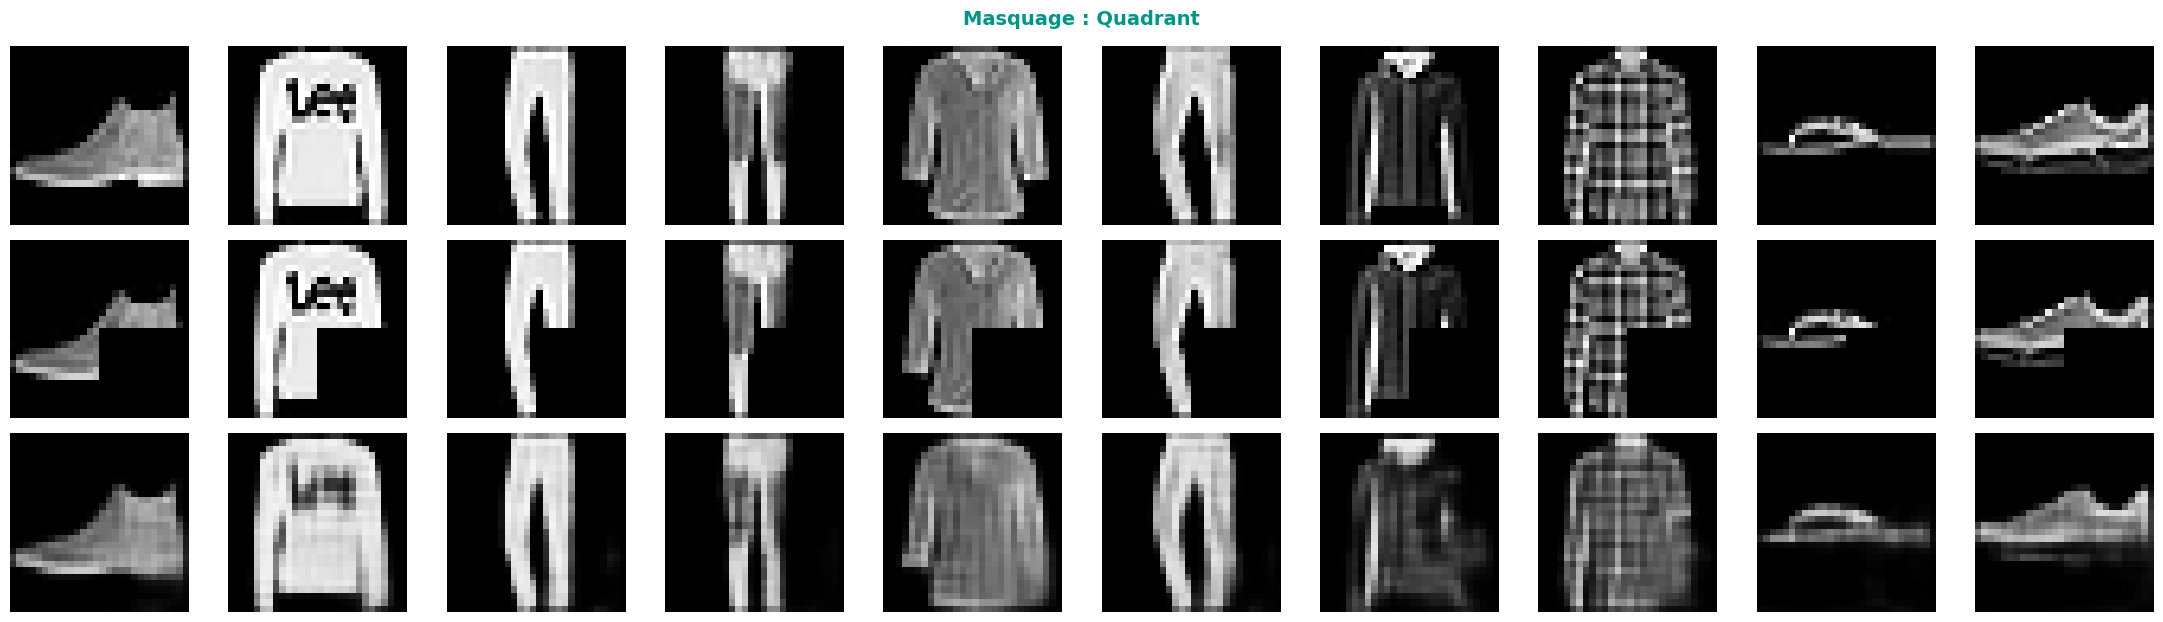

In [27]:

mask_colors = {
    'Aléatoire':   '#FF9800',
    'Lignes':      '#9C27B0',
    'Colonnes':    '#2196F3',
    'Patch carré': '#F44336',
    'Quadrant':    '#009688',
}

for mname in MASKING_FUNCS:
    color = mask_colors[mname]
    fig, axes = plt.subplots(3, N_VIS, figsize=(22, 3 * 2.1))
    fig.suptitle(f'Masquage : {mname}', fontsize=14, fontweight='bold', color=color)
    for row, (lbl, src) in enumerate([
        ('Original',    x_test),
        ('Masqué',      masked_test[mname]),
        ('Reconstruit', decoded_clean[mname]),
    ]):
        for col in range(N_VIS):
            axes[row, col].imshow(np.squeeze(np.array(src[col])), cmap='gray', vmin=0, vmax=1)
            axes[row, col].axis('off')
        axes[row, 0].set_ylabel(lbl, fontsize=9, rotation=0, labelpad=80, va='center')
    plt.tight_layout()
    plt.show()

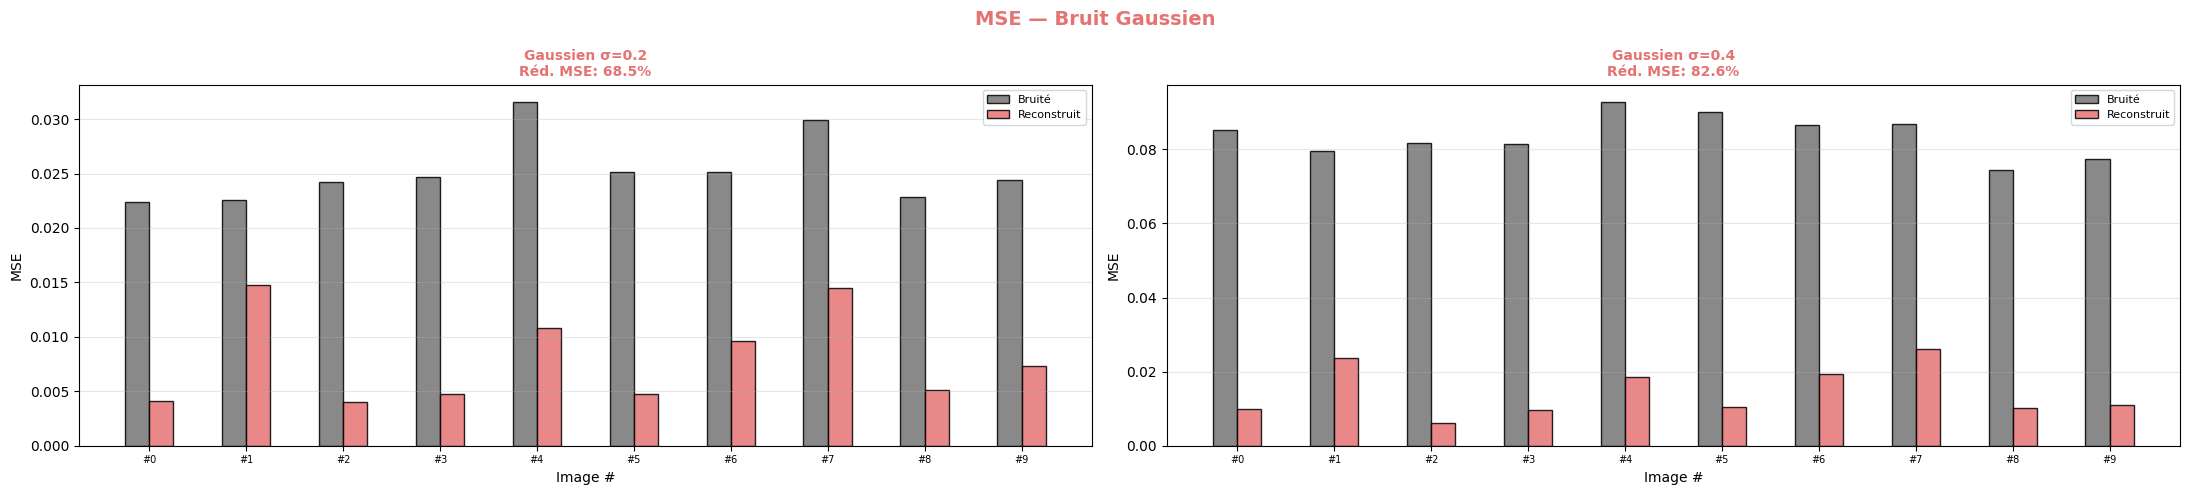

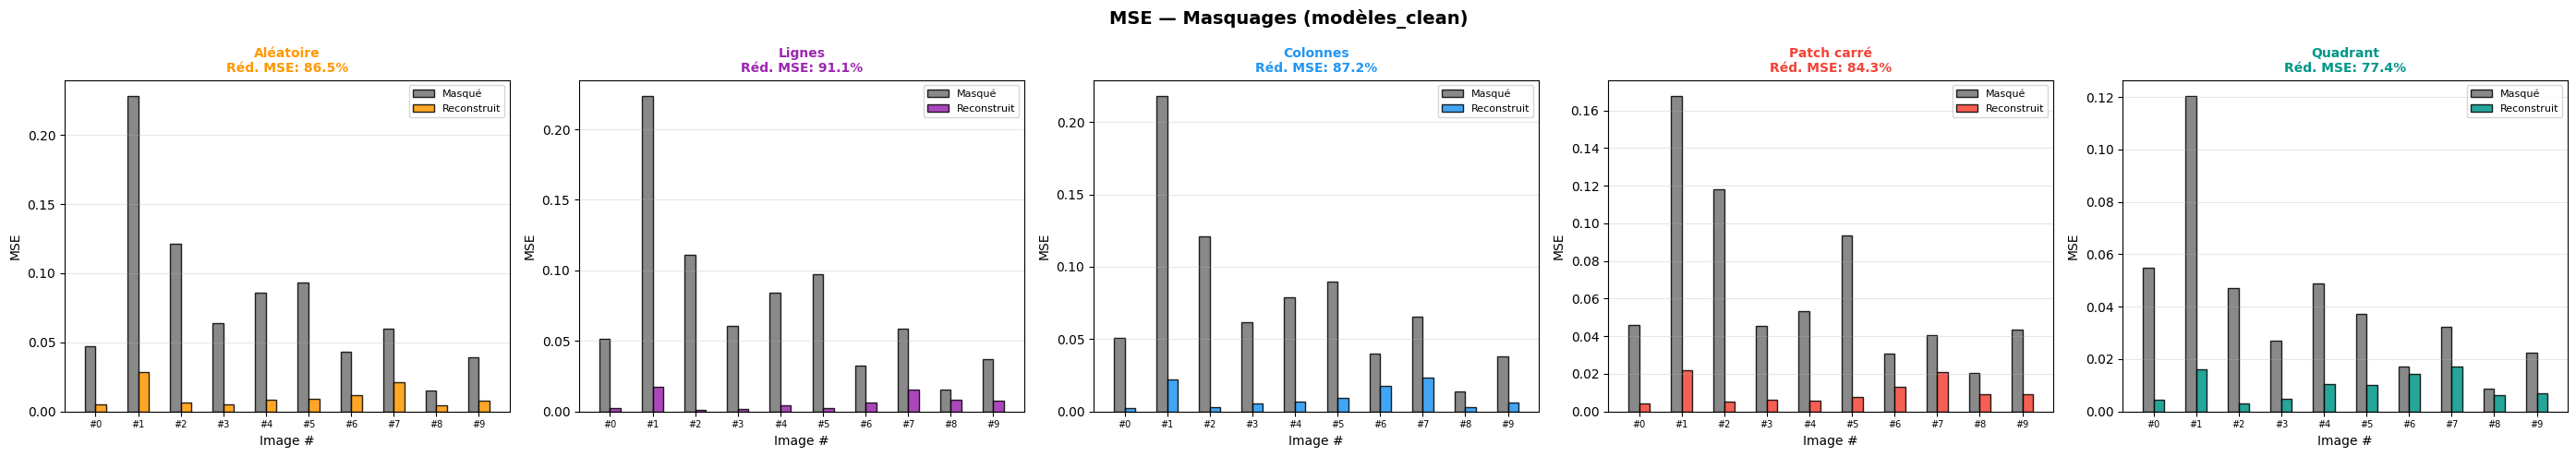


📊 MSE moyennes globales (sur 10 images) :
Méthode                  MSE Entrée  MSE Reconstruit  Réduction %
-----------------------------------------------------------------
Gaussien σ=0.2              0.02529          0.00797        68.5%
Gaussien σ=0.4              0.08359          0.01451        82.6%
Aléatoire                   0.07979          0.01073        86.5%
Lignes                      0.07730          0.00686        91.1%
Colonnes                    0.07783          0.00993        87.2%
Patch carré                 0.06600          0.01035        84.3%
Quadrant                    0.04166          0.00942        77.4%


In [28]:
from sklearn.metrics import mean_squared_error

def compute_mse_batch(original, reconstructed, n_eval):
    """Calcule MSE image par image."""
    mses = []
    for i in range(n_eval):
        orig = np.squeeze(np.array(original[i]))
        rec  = np.squeeze(np.array(reconstructed[i]))
        mses.append(mean_squared_error(orig.flatten(), rec.flatten()))
    return mses

n_mse = N_VIS
x_idx = np.arange(n_mse)
w = 0.25

# ─── Gaussien : 2 subplots (un par sigma) ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(22, 5))
fig.suptitle('MSE — Bruit Gaussien', fontsize=14, fontweight='bold', color='#E57373')

mse_summary = {}

for i, sigma in enumerate(SIGMAS):
    mdata = noisy_data[sigma]['x_test_noisy']
    rec   = decoded[sigma]['Bruit Gaussien']

    mse_msk = compute_mse_batch(x_test, mdata, n_mse)
    mse_rec = compute_mse_batch(x_test, rec,   n_mse)

    mse_summary[f'Gaussien σ={sigma}'] = {
        'msk': np.mean(mse_msk),
        'rec': np.mean(mse_rec),
    }

    red = (1 - np.mean(mse_rec) / np.mean(mse_msk)) * 100
    ax  = axes[i]
    ax.bar(x_idx - w/2, mse_msk, w, label='Bruité',       color='#757575', alpha=0.85, edgecolor='black')
    ax.bar(x_idx + w/2, mse_rec, w, label='Reconstruit',  color='#E57373', alpha=0.85, edgecolor='black')
    ax.set_title(f'Gaussien σ={sigma}\nRéd. MSE: {red:.1f}%', fontsize=10, fontweight='bold', color='#E57373')
    ax.set_xlabel('Image #'); ax.set_ylabel('MSE')
    ax.set_xticks(x_idx)
    ax.set_xticklabels([f'#{i}' for i in range(n_mse)], fontsize=7)
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ─── Masquages : 1 subplot par masquage ───────────────────────────────────────
mask_colors = {
    'Aléatoire':   '#FF9800',
    'Lignes':      '#9C27B0',
    'Colonnes':    '#2196F3',
    'Patch carré': '#F44336',
    'Quadrant':    '#009688',
}

fig, axes = plt.subplots(1, 5, figsize=(28, 5))
fig.suptitle('MSE — Masquages (modèles_clean)', fontsize=14, fontweight='bold')

for idx, mname in enumerate(MASKING_FUNCS):
    mdata = masked_test[mname]
    rec   = decoded_clean[mname]
    color = mask_colors[mname]

    mse_msk = compute_mse_batch(x_test, mdata, n_mse)
    mse_rec = compute_mse_batch(x_test, rec,   n_mse)

    mse_summary[mname] = {
        'msk': np.mean(mse_msk),
        'rec': np.mean(mse_rec),
    }

    red = (1 - np.mean(mse_rec) / np.mean(mse_msk)) * 100
    ax  = axes[idx]
    ax.bar(x_idx - w/2, mse_msk, w, label='Masqué',      color='#757575', alpha=0.85, edgecolor='black')
    ax.bar(x_idx + w/2, mse_rec, w, label='Reconstruit', color=color,     alpha=0.85, edgecolor='black')
    ax.set_title(f'{mname}\nRéd. MSE: {red:.1f}%', fontsize=10, fontweight='bold', color=color)
    ax.set_xlabel('Image #'); ax.set_ylabel('MSE')
    ax.set_xticks(x_idx)
    ax.set_xticklabels([f'#{i}' for i in range(n_mse)], fontsize=7)
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ─── Tableau récapitulatif ────────────────────────────────────────────────────
print('\n📊 MSE moyennes globales (sur {} images) :'.format(n_mse))
print(f'{"Méthode":<22} {"MSE Entrée":>12} {"MSE Reconstruit":>16} {"Réduction %":>12}')
print('-' * 65)
for mname, vals in mse_summary.items():
    red = (1 - vals['rec'] / vals['msk']) * 100
    print(f'{mname:<22} {vals["msk"]:>12.5f} {vals["rec"]:>16.5f} {red:>11.1f}%')

---
## 7C — Métriques Avancées par Masquage
### (SSIM, PSNR, MAE, Pearson)

| Métrique | Formule | Sens | Optimal |
|----------|---------|------|---------|
| **MSE** | $\frac{1}{N}\sum(y-\hat{y})^2$ | Erreur quadratique | → 0 |
| **MAE** | $\frac{1}{N}\sum|y-\hat{y}|$ | Erreur absolue | → 0 |
| **PSNR** | $10\log_{10}(1/\text{MSE})$ dB | Signal/Bruit | > 30 dB = bon |
| **SSIM** | Luminance × Contraste × Structure | Similarité perceptuelle | → 1 |
| **Pearson r** | $\frac{\text{Cov}(x,y)}{\sigma_x \sigma_y}$ | Corrélation linéaire | → 1 |

In [29]:
def compute_all_metrics(original, masked_arr, decoded_arr, n_eval=N_EVAL):
    records = []
    for i in range(n_eval):
        orig = np.squeeze(np.array(original[i]))
        mskd = np.squeeze(np.array(masked_arr[i]))
        rec  = np.squeeze(np.array(decoded_arr[i]))

        r_m, _ = pearsonr(orig.flatten(), mskd.flatten())
        r_r, _ = pearsonr(orig.flatten(), rec.flatten())

        records.append({
            'MSE_M':     mean_squared_error(orig.flatten(), mskd.flatten()),
            'MSE_R':     mean_squared_error(orig.flatten(), rec.flatten()),
            'MAE_M':     float(np.mean(np.abs(orig - mskd))),
            'MAE_R':     float(np.mean(np.abs(orig - rec))),
            'PSNR_M':    psnr(orig, mskd, data_range=1.0),
            'PSNR_R':    psnr(orig, rec,  data_range=1.0),
            'SSIM_M':    ssim(orig, mskd, data_range=1.0),
            'SSIM_R':    ssim(orig, rec,  data_range=1.0),
            'Pearson_M': r_m,
            'Pearson_R': r_r,
        })
    df = pd.DataFrame(records)
    means = df.mean()
    means['ΔMSE']     = means['MSE_M']     - means['MSE_R']
    means['ΔMAE']     = means['MAE_M']     - means['MAE_R']
    means['ΔPSNR']    = means['PSNR_R']    - means['PSNR_M']
    means['ΔSSIM']    = means['SSIM_R']    - means['SSIM_M']
    means['ΔPearson'] = means['Pearson_R'] - means['Pearson_M']
    return means.round(4)

all_metrics = {}

# ─── Bruit Gaussien : decoded[sigma]['Bruit Gaussien'] ────────────────────────
for sigma in SIGMAS:
    m = compute_all_metrics(
        x_test,
        noisy_data[sigma]['x_test_noisy'],
        decoded[sigma]['Bruit Gaussien']
    )
    all_metrics[('Bruit Gaussien', sigma)] = m
    print(f'✅ Métriques calculées : Bruit Gaussien × σ={sigma}')

# ─── Masquages : decoded_clean[mname] (un seul modèle, pas de sigma) ──────────
for mname in MASKING_FUNCS:
    m = compute_all_metrics(
        x_test,
        masked_test[mname],
        decoded_clean[mname]
    )
    all_metrics[(mname, 'clean')] = m
    print(f'✅ Métriques calculées : {mname:<15} × modèle clean')

print(f'\n✅ Total : {len(all_metrics)} combinaisons évaluées sur {N_EVAL} images chacune.')

✅ Métriques calculées : Bruit Gaussien × σ=0.2
✅ Métriques calculées : Bruit Gaussien × σ=0.4
✅ Métriques calculées : Aléatoire       × modèle clean
✅ Métriques calculées : Lignes          × modèle clean
✅ Métriques calculées : Colonnes        × modèle clean
✅ Métriques calculées : Patch carré     × modèle clean
✅ Métriques calculées : Quadrant        × modèle clean

✅ Total : 7 combinaisons évaluées sur 200 images chacune.


### 7C.1 — Tableau Comparatif Complet par Masquage

In [30]:
MASK_ORDER = ['Bruit Gaussien', 'Aléatoire', 'Lignes', 'Colonnes', 'Patch carré', 'Quadrant']

rows = []
for mname in MASK_ORDER:
    if mname == 'Bruit Gaussien':
        # deux lignes : une par sigma
        for sigma in SIGMAS:
            key = (mname, sigma)
            if key in all_metrics:
                m = all_metrics[key]
                rows.append({
                    'Masquage':         mname,
                    'Modèle':           f'σ={sigma}',
                    'MSE Masqué':       m['MSE_M'],
                    'MSE Reconstruit':  m['MSE_R'],
                    'ΔMSE ↓':           m['ΔMSE'],
                    'MAE Masqué':       m['MAE_M'],
                    'MAE Reconstruit':  m['MAE_R'],
                    'PSNR Masqué':      m['PSNR_M'],
                    'PSNR Reconstruit': m['PSNR_R'],
                    'ΔPSNR ↑':          m['ΔPSNR'],
                    'SSIM Masqué':      m['SSIM_M'],
                    'SSIM Reconstruit': m['SSIM_R'],
                    'ΔSSIM ↑':          m['ΔSSIM'],
                    'Pearson Masqué':   m['Pearson_M'],
                    'Pearson Recon.':   m['Pearson_R'],
                })
    else:
        # une seule ligne : modèle clean
        key = (mname, 'clean')
        if key in all_metrics:
            m = all_metrics[key]
            rows.append({
                'Masquage':         mname,
                'Modèle':           'clean',
                'MSE Masqué':       m['MSE_M'],
                'MSE Reconstruit':  m['MSE_R'],
                'ΔMSE ↓':           m['ΔMSE'],
                'MAE Masqué':       m['MAE_M'],
                'MAE Reconstruit':  m['MAE_R'],
                'PSNR Masqué':      m['PSNR_M'],
                'PSNR Reconstruit': m['PSNR_R'],
                'ΔPSNR ↑':          m['ΔPSNR'],
                'SSIM Masqué':      m['SSIM_M'],
                'SSIM Reconstruit': m['SSIM_R'],
                'ΔSSIM ↑':          m['ΔSSIM'],
                'Pearson Masqué':   m['Pearson_M'],
                'Pearson Recon.':   m['Pearson_R'],
            })

df_main = pd.DataFrame(rows).round(4)

print('🏆 Tableau Comparatif Complet — Toutes Méthodes')
display(df_main.style
    .background_gradient(cmap='RdYlGn',   subset=['SSIM Reconstruit', 'ΔSSIM ↑', 'Pearson Recon.'])
    .background_gradient(cmap='RdYlGn',   subset=['PSNR Reconstruit', 'ΔPSNR ↑'])
    .background_gradient(cmap='RdYlGn_r', subset=['MSE Reconstruit', 'MAE Reconstruit'])
    .background_gradient(cmap='RdYlGn',   subset=['ΔMSE ↓'])
    .format('{:.4f}', subset=df_main.columns[2:])
    .set_caption('🏆 Tableau Comparatif Complet — Moyennes sur {} images | Vert = Meilleur'.format(N_EVAL))
    .set_table_styles([{'selector': 'th', 'props': [('font-weight', 'bold'), ('font-size', '10px'),
                                                     ('text-align', 'center'), ('white-space', 'nowrap')]}])
    .hide(axis='index')
)

🏆 Tableau Comparatif Complet — Toutes Méthodes


Masquage,Modèle,MSE Masqué,MSE Reconstruit,ΔMSE ↓,MAE Masqué,MAE Reconstruit,PSNR Masqué,PSNR Reconstruit,ΔPSNR ↑,SSIM Masqué,SSIM Reconstruit,ΔSSIM ↑,Pearson Masqué,Pearson Recon.
Bruit Gaussien,σ=0.2,0.0253,0.0072,0.0181,0.1083,0.0476,16.0091,21.7245,5.7154,0.5650,0.7973,0.2323,0.8642,0.9521
Bruit Gaussien,σ=0.4,0.0846,0.0129,0.0717,0.1970,0.0636,10.7386,19.1882,8.4496,0.3616,0.6804,0.3188,0.6349,0.9132
Aléatoire,clean,0.1079,0.0087,0.0992,0.1473,0.0451,10.6954,21.1529,10.4575,0.4134,0.8020,0.3887,0.5986,0.9474
Lignes,clean,0.1085,0.0055,0.1030,0.1476,0.0346,10.6457,23.4436,12.7978,0.4087,0.8677,0.4590,0.5938,0.9630
Colonnes,clean,0.1084,0.0074,0.1010,0.1478,0.0419,10.6471,21.9242,11.2771,0.4080,0.8219,0.4139,0.5949,0.9546
Patch carré,clean,0.0964,0.0081,0.0882,0.1307,0.0441,11.1326,21.6390,10.5063,0.4467,0.7710,0.3243,0.6230,0.9480
Quadrant,clean,0.0614,0.0081,0.0533,0.0832,0.0447,13.1385,21.6752,8.5366,0.7042,0.8189,0.1147,0.7541,0.9509


### 7C.2 — Tableaux de Gains (Δ) par Masquage

In [31]:
gain_rows = []
for mname in MASK_ORDER:
    if mname == 'Bruit Gaussien':
        for sigma in SIGMAS:
            key = (mname, sigma)
            if key in all_metrics:
                m = all_metrics[key]
                gain_rows.append({
                    'Masquage':   mname,
                    'Modèle':     f'σ={sigma}',
                    'ΔMSE ↓':     m['ΔMSE'],
                    'ΔMAE ↓':     m['ΔMAE'],
                    'ΔPSNR ↑':    m['ΔPSNR'],
                    'ΔSSIM ↑':    m['ΔSSIM'],
                    'ΔPearson ↑': m['ΔPearson'],
                })
    else:
        key = (mname, 'clean')
        if key in all_metrics:
            m = all_metrics[key]
            gain_rows.append({
                'Masquage':   mname,
                'Modèle':     'clean',
                'ΔMSE ↓':     m['ΔMSE'],
                'ΔMAE ↓':     m['ΔMAE'],
                'ΔPSNR ↑':    m['ΔPSNR'],
                'ΔSSIM ↑':    m['ΔSSIM'],
                'ΔPearson ↑': m['ΔPearson'],
            })

df_gain = pd.DataFrame(gain_rows).round(4)

display(df_gain.style
    .background_gradient(cmap='RdYlGn', subset=['ΔSSIM ↑', 'ΔPSNR ↑', 'ΔPearson ↑', 'ΔMSE ↓', 'ΔMAE ↓'])
    .format('{:+.4f}', subset=df_gain.columns[2:])
    .set_caption("📈 Tableau des Gains — Amélioration apportée par l'Auto-Encodeur (Vert = meilleure amélioration)")
    .set_table_styles([{'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]}])
    .hide(axis='index')
)

Masquage,Modèle,ΔMSE ↓,ΔMAE ↓,ΔPSNR ↑,ΔSSIM ↑,ΔPearson ↑
Bruit Gaussien,σ=0.2,+0.0181,+0.0607,+5.7154,+0.2323,+0.0878
Bruit Gaussien,σ=0.4,+0.0717,+0.1334,+8.4496,+0.3188,+0.2783
Aléatoire,clean,+0.0992,+0.1022,+10.4575,+0.3887,+0.3488
Lignes,clean,+0.1030,+0.1130,+12.7978,+0.4590,+0.3692
Colonnes,clean,+0.1010,+0.1059,+11.2771,+0.4139,+0.3597
Patch carré,clean,+0.0882,+0.0866,+10.5063,+0.3243,+0.3250
Quadrant,clean,+0.0533,+0.0386,+8.5366,+0.1147,+0.1968


### 7C.3 — Visualisation des métriques par masquage

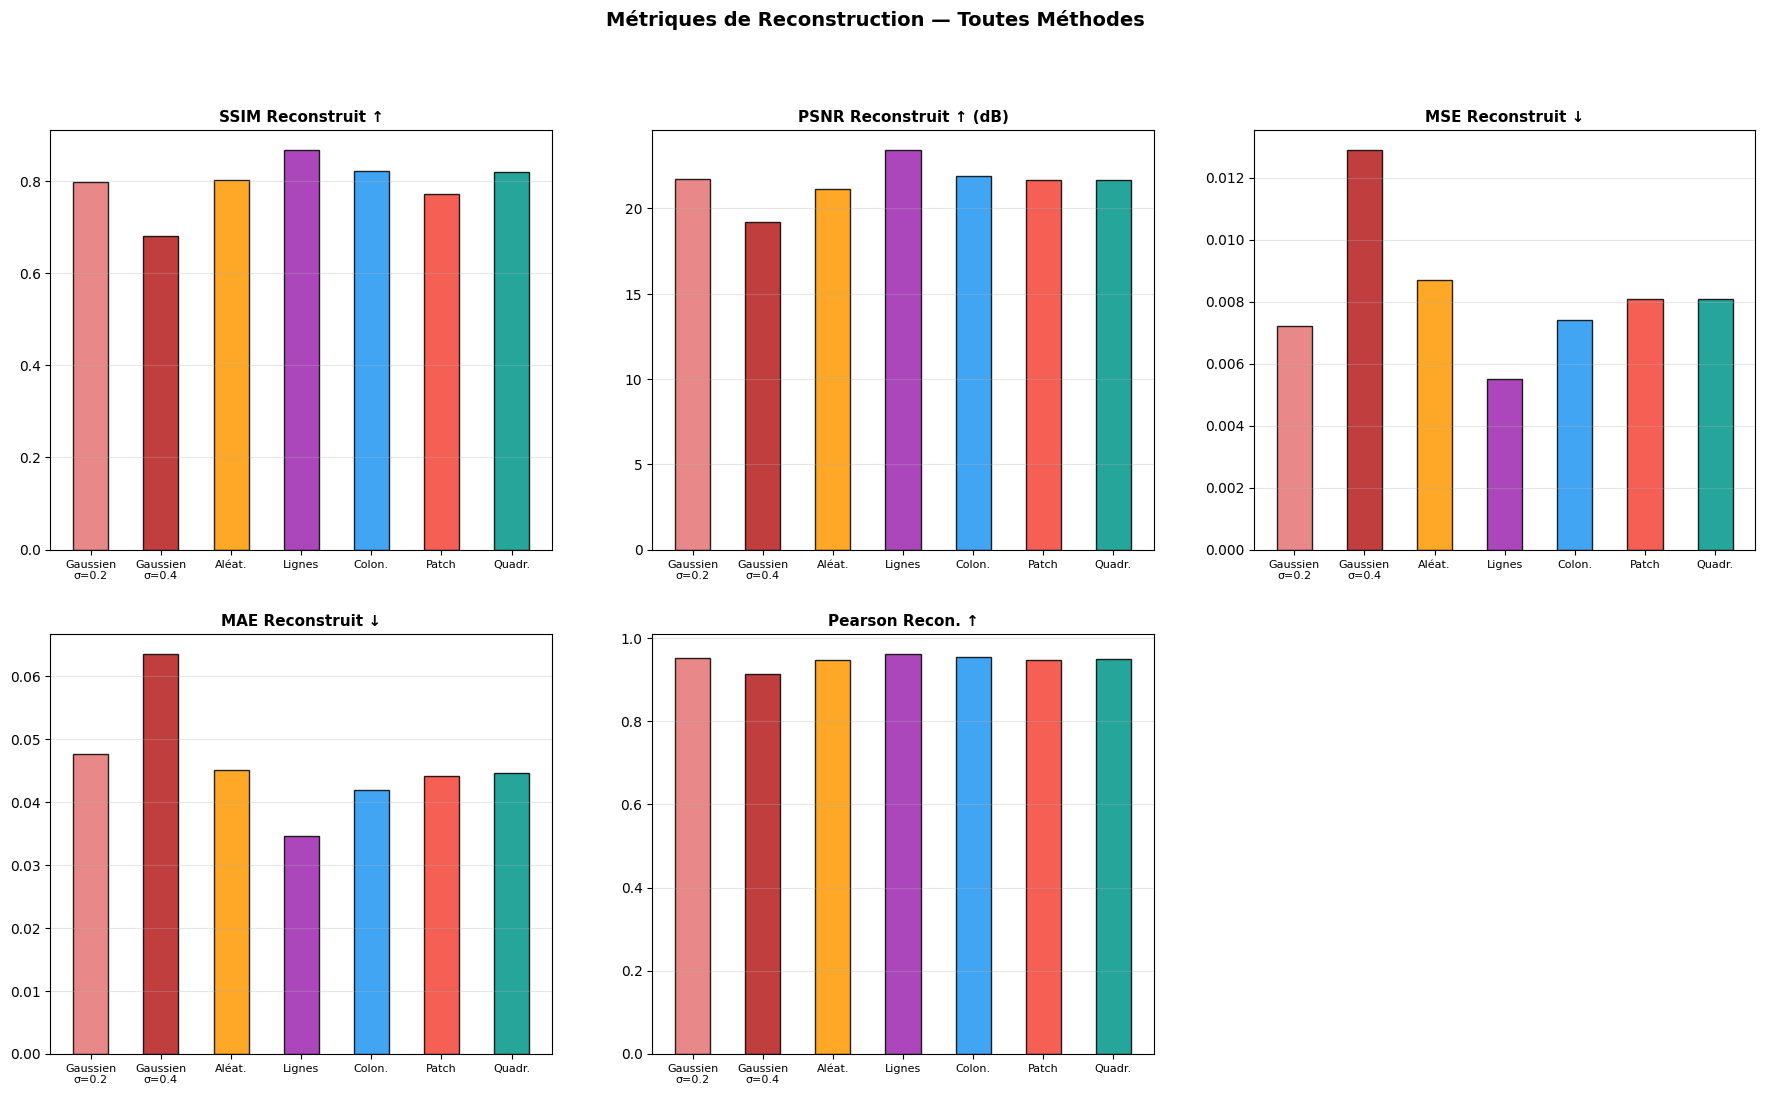

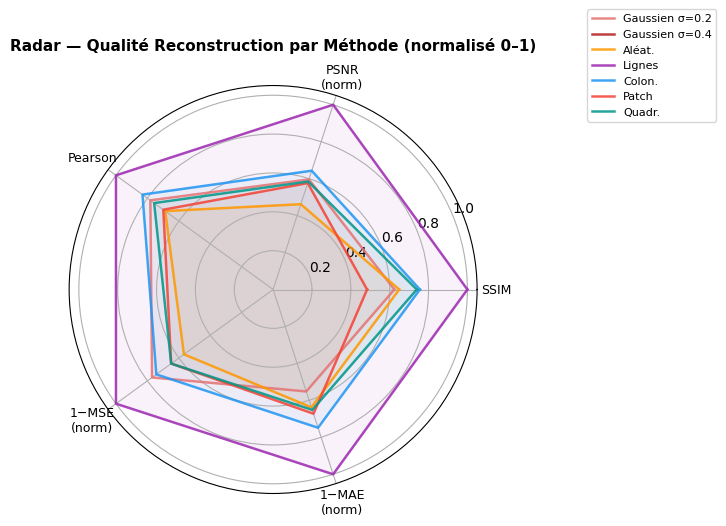

In [32]:
metrics_to_plot = [
    ('SSIM Reconstruit ↑',     'SSIM_R'),
    ('PSNR Reconstruit ↑ (dB)','PSNR_R'),
    ('MSE Reconstruit ↓',      'MSE_R'),
    ('MAE Reconstruit ↓',      'MAE_R'),
    ('Pearson Recon. ↑',       'Pearson_R'),
]

# ─── Labels courts pour l'axe X ───────────────────────────────────────────────
SHORT_LABELS = ['Gaussien\nσ=0.2', 'Gaussien\nσ=0.4', 'Aléat.', 'Lignes', 'Colon.', 'Patch', 'Quadr.']

# ─── Clés unifiées pour récupérer les métriques ───────────────────────────────
ALL_KEYS = [
    ('Bruit Gaussien', 0.2),
    ('Bruit Gaussien', 0.4),
    ('Aléatoire',      'clean'),
    ('Lignes',         'clean'),
    ('Colonnes',       'clean'),
    ('Patch carré',    'clean'),
    ('Quadrant',       'clean'),
]

fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle('Métriques de Reconstruction — Toutes Méthodes',
             fontsize=14, fontweight='bold')
axes_flat = axes.flatten()

x = np.arange(len(ALL_KEYS))
w = 0.5

for idx, (met_label, met_key) in enumerate(metrics_to_plot):
    ax = axes_flat[idx]
    vals  = [all_metrics.get(k, {}).get(met_key, 0) for k in ALL_KEYS]
    colors = ['#E57373', '#B71C1C',        # gaussien 0.2 / 0.4
              '#FF9800', '#9C27B0', '#2196F3', '#F44336', '#009688']  # masquages

    ax.bar(x, vals, w, color=colors, alpha=0.85, edgecolor='black')
    ax.set_title(met_label, fontsize=11, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(SHORT_LABELS, fontsize=8)
    ax.grid(axis='y', alpha=0.3)

# ─── Radar chart ──────────────────────────────────────────────────────────────
axes_flat[5].axis('off')

fig2, ax_radar = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax_radar.set_title('Radar — Qualité Reconstruction par Méthode (normalisé 0–1)',
                   fontsize=11, fontweight='bold', pad=25)

categories = ['SSIM', 'PSNR\n(norm)', 'Pearson', '1−MSE\n(norm)', '1−MAE\n(norm)']
angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist() + [0]

def norm01(v):
    a = np.array(v, dtype=float)
    rng = a.max() - a.min()
    return ((a - a.min()) / (rng + 1e-9)).tolist()

ssim_v = [all_metrics.get(k, {}).get('SSIM_R',    0) for k in ALL_KEYS]
psnr_v = [all_metrics.get(k, {}).get('PSNR_R',    0) for k in ALL_KEYS]
pear_v = [all_metrics.get(k, {}).get('Pearson_R', 0) for k in ALL_KEYS]
mse_v  = [all_metrics.get(k, {}).get('MSE_R',     1) for k in ALL_KEYS]
mae_v  = [all_metrics.get(k, {}).get('MAE_R',     1) for k in ALL_KEYS]

ssim_n = norm01(ssim_v)
psnr_n = norm01(psnr_v)
pear_n = norm01(pear_v)
mse_n  = [1-v for v in norm01(mse_v)]
mae_n  = [1-v for v in norm01(mae_v)]

PALETTE = ['#E57373','#B71C1C','#FF9800','#9C27B0','#2196F3','#F44336','#009688']

for i, (key, c, lbl) in enumerate(zip(ALL_KEYS, PALETTE, SHORT_LABELS)):
    vals = [ssim_n[i], psnr_n[i], pear_n[i], mse_n[i], mae_n[i]] + [ssim_n[i]]
    ax_radar.plot(angles, vals, lw=1.8, color=c, alpha=0.85,
                  label=lbl.replace('\n', ' '))
    ax_radar.fill(angles, vals, alpha=0.06, color=c)

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(categories, fontsize=9)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.6, 1.2), fontsize=8)
ax_radar.grid(True)

plt.tight_layout()
plt.show()

---
## 8. Comparaison Croisée σ=0.2 vs σ=0.4

Cette section répond à la question centrale : **quel niveau d'entraînement produit le meilleur décodeur ?**

On compare les deux modèles sur chaque type de masquage séparément.

In [34]:
# ─── Comparaison directe σ=0.2 vs σ=0.4 — Bruit Gaussien uniquement ──────────
m02 = all_metrics.get(('Bruit Gaussien', 0.2), None)
m04 = all_metrics.get(('Bruit Gaussien', 0.4), None)

winner_ssim    = 'σ=0.2' if m02['SSIM_R']    > m04['SSIM_R']    else 'σ=0.4'
winner_psnr    = 'σ=0.2' if m02['PSNR_R']    > m04['PSNR_R']    else 'σ=0.4'
winner_mse     = 'σ=0.2' if m02['MSE_R']     < m04['MSE_R']     else 'σ=0.4'
winner_pearson = 'σ=0.2' if m02['Pearson_R'] > m04['Pearson_R'] else 'σ=0.4'
votes        = [winner_ssim, winner_psnr, winner_mse, winner_pearson]
best_overall = 'σ=0.2' if votes.count('σ=0.2') >= 3 else 'σ=0.4'

df_gauss_compare = pd.DataFrame([{
    'Masquage':        'Bruit Gaussien',
    'SSIM σ=0.2':      round(m02['SSIM_R'],    4),
    'SSIM σ=0.4':      round(m04['SSIM_R'],    4),
    'ΔSSIM (0.2−0.4)': round(m02['SSIM_R']    - m04['SSIM_R'],    4),
    'PSNR σ=0.2':      round(m02['PSNR_R'],    3),
    'PSNR σ=0.4':      round(m04['PSNR_R'],    3),
    'MSE σ=0.2':       round(m02['MSE_R'],     5),
    'MSE σ=0.4':       round(m04['MSE_R'],     5),
    'Pearson σ=0.2':   round(m02['Pearson_R'], 4),
    'Pearson σ=0.4':   round(m04['Pearson_R'], 4),
    'Meilleur global': best_overall,
}])

def highlight_winner(row):
    styles = [''] * len(row)
    idx = row.index.tolist()
    pairs = [
        ('SSIM σ=0.2',    'SSIM σ=0.4',    True),
        ('PSNR σ=0.2',    'PSNR σ=0.4',    True),
        ('MSE σ=0.2',     'MSE σ=0.4',     False),
        ('Pearson σ=0.2', 'Pearson σ=0.4', True),
    ]
    for col_a, col_b, higher_better in pairs:
        if col_a in idx and col_b in idx:
            va, vb = row[col_a], row[col_b]
            win_a = (va > vb) if higher_better else (va < vb)
            styles[idx.index(col_a)] = 'background-color: #C8E6C9; font-weight:bold' if win_a  else 'background-color: #FFCDD2'
            styles[idx.index(col_b)] = 'background-color: #FFCDD2'                   if win_a  else 'background-color: #C8E6C9; font-weight:bold'
    if 'Meilleur global' in idx:
        v = row['Meilleur global']
        styles[idx.index('Meilleur global')] = (
            'background-color: #1565C0; color: white; font-weight:bold' if v == 'σ=0.2'
            else 'background-color: #B71C1C; color: white; font-weight:bold')
    return styles

print('🔵 σ=0.2 — 🔴 σ=0.4   |   Vert = meilleur sur cette métrique')
display(df_gauss_compare.style
    .apply(highlight_winner, axis=1)
    .set_caption('🆚 Comparaison Directe — Modèle Gaussien σ=0.2 vs σ=0.4 (vert = gagne)')
    .set_table_styles([{'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center'),
                                                     ('font-size', '11px'), ('white-space', 'nowrap')]}])
    .hide(axis='index')
)

# ─── Tableau récapitulatif masquages (modèles clean) ──────────────────────────
clean_rows = []
for mname in MASKING_FUNCS:
    m = all_metrics.get((mname, 'clean'), None)
    if m is None:
        continue
    clean_rows.append({
        'Masquage': mname,
        'SSIM':     round(m['SSIM_R'],    4),
        'PSNR':     round(m['PSNR_R'],    3),
        'MSE':      round(m['MSE_R'],     5),
        'MAE':      round(m['MAE_R'],     5),
        'Pearson':  round(m['Pearson_R'], 4),
        'ΔSSIM ↑':  round(m['ΔSSIM'],    4),
        'ΔPSNR ↑':  round(m['ΔPSNR'],    3),
        'ΔMSE ↓':   round(m['ΔMSE'],     5),
    })

df_clean = pd.DataFrame(clean_rows)

display(df_clean.style
    .background_gradient(cmap='RdYlGn',   subset=['SSIM', 'PSNR', 'Pearson', 'ΔSSIM ↑', 'ΔPSNR ↑'])
    .background_gradient(cmap='RdYlGn_r', subset=['MSE',  'MAE'])
    .background_gradient(cmap='RdYlGn',   subset=['ΔMSE ↓'])
    .format('{:.4f}', subset=['SSIM', 'Pearson', 'ΔSSIM ↑', 'ΔMSE ↓'])
    .format('{:.3f}', subset=['PSNR', 'ΔPSNR ↑'])
    .format('{:.5f}', subset=['MSE',  'MAE'])
    .set_caption('📊 Métriques Modèles Clean — Un modèle par type de masquage (vert = meilleur)')
    .set_table_styles([{'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center'),
                                                     ('font-size', '11px'), ('white-space', 'nowrap')]}])
    .hide(axis='index')
)

🔵 σ=0.2 — 🔴 σ=0.4   |   Vert = meilleur sur cette métrique


Masquage,SSIM σ=0.2,SSIM σ=0.4,ΔSSIM (0.2−0.4),PSNR σ=0.2,PSNR σ=0.4,MSE σ=0.2,MSE σ=0.4,Pearson σ=0.2,Pearson σ=0.4,Meilleur global
Bruit Gaussien,0.797300,0.680400,0.116900,21.724000,19.188000,0.007200,0.012900,0.952100,0.913200,σ=0.2


Masquage,SSIM,PSNR,MSE,MAE,Pearson,ΔSSIM ↑,ΔPSNR ↑,ΔMSE ↓
Aléatoire,0.8020,21.153,0.00870,0.04510,0.9474,0.3887,10.458,0.0992
Lignes,0.8677,23.444,0.00550,0.03460,0.9630,0.4590,12.798,0.1030
Colonnes,0.8219,21.924,0.00740,0.04190,0.9546,0.4139,11.277,0.1010
Patch carré,0.7710,21.639,0.00810,0.04410,0.9480,0.3243,10.506,0.0882
Quadrant,0.8189,21.675,0.00810,0.04470,0.9509,0.1147,8.537,0.0533


### 8.1 — Score global σ=0.2 vs σ=0.4 : combien de victoires par méthode ?

📊 Détail des victoires — Bruit Gaussien σ=0.2 vs σ=0.4 :


,σ=0.2,σ=0.4,Gagnant
Métrique,,,
SSIM,0.797300,0.680400,🔵 σ=0.2
PSNR,21.724500,19.188200,🔵 σ=0.2
MSE,0.007200,0.012900,🔵 σ=0.2
MAE,0.047600,0.063600,🔵 σ=0.2
Pearson,0.952100,0.913200,🔵 σ=0.2



🏆 Vainqueur global Bruit Gaussien : 🔵 σ=0.2  (5–0)


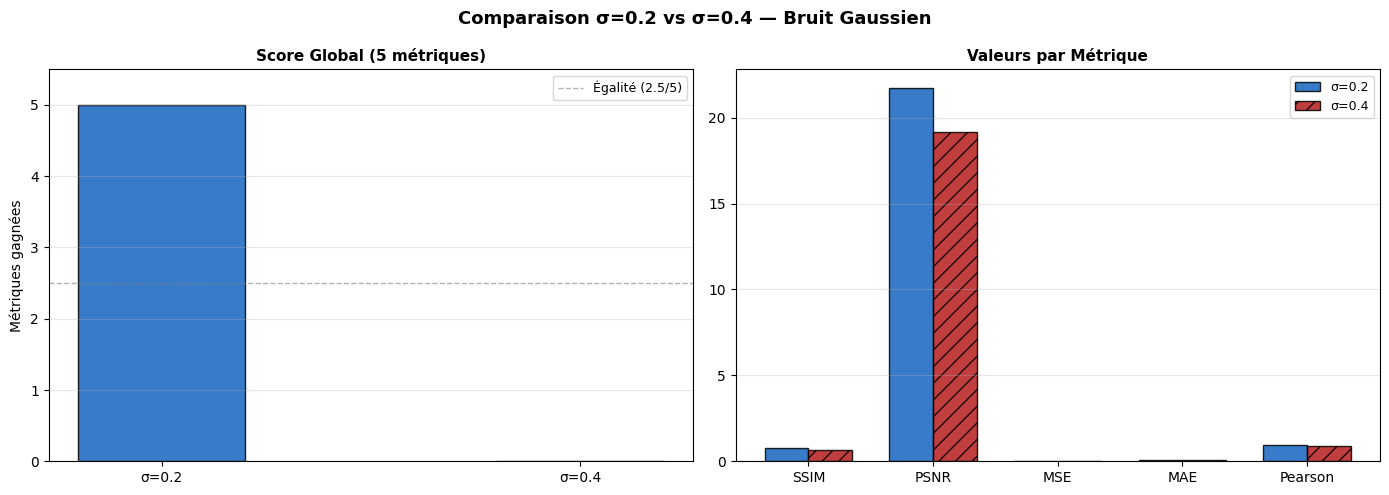


📊 Classement modèles clean par métrique :


,Masquage,SSIM,PSNR,MSE,MAE,Pearson
Rang,,,,,,
1,Lignes,0.867700,23.444000,0.005500,0.034600,0.963000
2,Colonnes,0.821900,21.924000,0.007400,0.041900,0.954600
3,Quadrant,0.818900,21.675000,0.008100,0.044700,0.950900
4,Aléatoire,0.802000,21.153000,0.008700,0.045100,0.947400
5,Patch carré,0.771000,21.639000,0.008100,0.044100,0.948000


In [37]:
metrics_for_vote = [
    ('SSIM_R',    True,  'SSIM'),
    ('PSNR_R',    True,  'PSNR'),
    ('MSE_R',     False, 'MSE'),
    ('MAE_R',     False, 'MAE'),
    ('Pearson_R', True,  'Pearson'),
]

# ─── Vote σ=0.2 vs σ=0.4 — Bruit Gaussien uniquement ─────────────────────────
m02 = all_metrics.get(('Bruit Gaussien', 0.2), None)
m04 = all_metrics.get(('Bruit Gaussien', 0.4), None)

votes = {'σ=0.2': 0, 'σ=0.4': 0}
vote_detail = {}

for key, higher_better, label in metrics_for_vote:
    v02, v04 = m02[key], m04[key]
    if higher_better:
        winner = 'σ=0.2' if v02 >= v04 else 'σ=0.4'
    else:
        winner = 'σ=0.2' if v02 <= v04 else 'σ=0.4'
    votes[winner] += 1
    vote_detail[label] = {
        'σ=0.2':   round(v02, 4),
        'σ=0.4':   round(v04, 4),
        'Gagnant': f'🔵 {winner}' if winner == 'σ=0.2' else f'🔴 {winner}'
    }

vote_df = pd.DataFrame(vote_detail).T
vote_df.index.name = 'Métrique'

print('📊 Détail des victoires — Bruit Gaussien σ=0.2 vs σ=0.4 :')
display(vote_df.style
    .set_caption(f'🏅 Bruit Gaussien : σ=0.2 gagne {votes["σ=0.2"]}/5 | σ=0.4 gagne {votes["σ=0.4"]}/5')
    .set_table_styles([{'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]}])
)

vainqueur = '🔵 σ=0.2' if votes['σ=0.2'] > votes['σ=0.4'] else '🔴 σ=0.4'
print(f'\n🏆 Vainqueur global Bruit Gaussien : {vainqueur}  ({votes["σ=0.2"]}–{votes["σ=0.4"]})')

# ─── Graphique votes ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparaison σ=0.2 vs σ=0.4 — Bruit Gaussien', fontsize=13, fontweight='bold')

# Barres victoires globales
ax = axes[0]
ax.bar(['σ=0.2', 'σ=0.4'], [votes['σ=0.2'], votes['σ=0.4']],
       color=['#1565C0', '#B71C1C'], edgecolor='black', alpha=0.85, width=0.4)
ax.axhline(2.5, color='gray', linestyle='--', lw=1, alpha=0.6, label='Égalité (2.5/5)')
ax.set_title('Score Global (5 métriques)', fontsize=11, fontweight='bold')
ax.set_ylabel('Métriques gagnées')
ax.set_ylim(0, 5.5)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Barres par métrique
ax2 = axes[1]
met_labels = [m[2] for m in metrics_for_vote]
vals_02    = [m02[m[0]] for m in metrics_for_vote]
vals_04    = [m04[m[0]] for m in metrics_for_vote]
x = np.arange(len(met_labels))
w = 0.35
ax2.bar(x - w/2, vals_02, w, color='#1565C0', label='σ=0.2', edgecolor='black', alpha=0.85)
ax2.bar(x + w/2, vals_04, w, color='#B71C1C', label='σ=0.4', edgecolor='black', alpha=0.85, hatch='//')
ax2.set_title('Valeurs par Métrique', fontsize=11, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(met_labels, fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ─── Classement modèles clean par masquage ────────────────────────────────────
print('\n📊 Classement modèles clean par métrique :')
rank_rows = []
for mname in MASKING_FUNCS:
    m = all_metrics.get((mname, 'clean'), None)
    if m is None:
        continue
    rank_rows.append({
        'Masquage': mname,
        'SSIM':     round(m['SSIM_R'],    4),
        'PSNR':     round(m['PSNR_R'],    3),
        'MSE':      round(m['MSE_R'],     5),
        'MAE':      round(m['MAE_R'],     5),
        'Pearson':  round(m['Pearson_R'], 4),
    })

df_rank = pd.DataFrame(rank_rows).sort_values('SSIM', ascending=False).reset_index(drop=True)
df_rank.index += 1
df_rank.index.name = 'Rang'

display(df_rank.style
    .background_gradient(cmap='RdYlGn',   subset=['SSIM', 'PSNR', 'Pearson'])
    .background_gradient(cmap='RdYlGn_r', subset=['MSE',  'MAE'])
    .set_caption('🏅 Classement Modèles Clean — trié par SSIM décroissant (vert = meilleur)')
    .set_table_styles([{'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]}])
)

### 8.2 — Heatmap globale SSIM Reconstruit par Masquage × Sigma

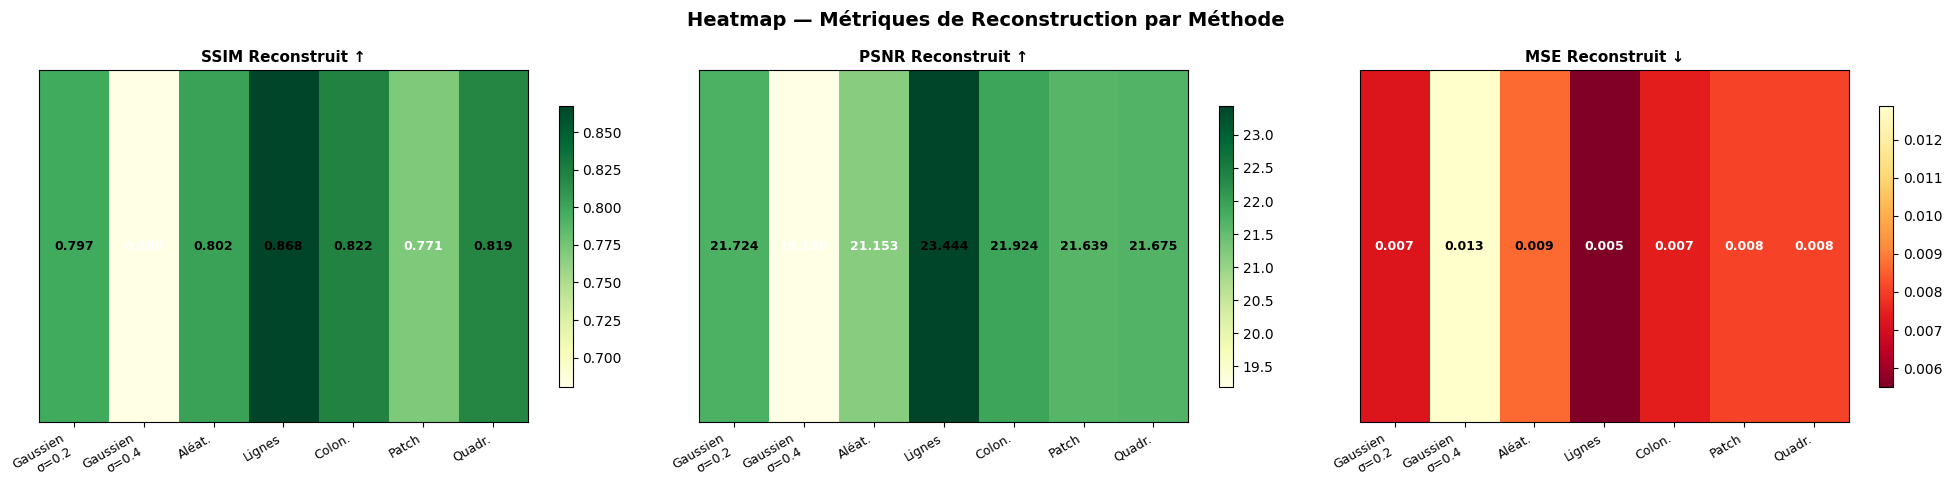

In [38]:
key_metrics = [
    ('SSIM_R', 'SSIM Reconstruit ↑', 'YlGn'),
    ('PSNR_R', 'PSNR Reconstruit ↑', 'YlGn'),
    ('MSE_R',  'MSE Reconstruit ↓',  'YlOrRd'),
]

# ─── Clés et labels unifiés ───────────────────────────────────────────────────
ALL_KEYS    = [
    ('Bruit Gaussien', 0.2),
    ('Bruit Gaussien', 0.4),
    ('Aléatoire',      'clean'),
    ('Lignes',         'clean'),
    ('Colonnes',       'clean'),
    ('Patch carré',    'clean'),
    ('Quadrant',       'clean'),
]
ALL_LABELS  = ['Gaussien\nσ=0.2', 'Gaussien\nσ=0.4',
               'Aléat.', 'Lignes', 'Colon.', 'Patch', 'Quadr.']

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Heatmap — Métriques de Reconstruction par Méthode',
             fontsize=14, fontweight='bold')

for ax, (met_key, met_label, cmap) in zip(axes, key_metrics):
    # matrice 1 ligne × N méthodes
    matrix = np.array([[all_metrics.get(k, {}).get(met_key, 0) for k in ALL_KEYS]])

    invert = (met_key == 'MSE_R')
    im = ax.imshow(matrix, cmap=cmap + '_r' if invert else cmap, aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.8)

    ax.set_xticks(range(len(ALL_KEYS)))
    ax.set_xticklabels(ALL_LABELS, rotation=30, ha='right', fontsize=9)
    ax.set_yticks([])
    ax.set_title(met_label, fontsize=11, fontweight='bold')

    for j in range(len(ALL_KEYS)):
        val = matrix[0, j]
        ax.text(j, 0, f'{val:.3f}', ha='center', va='center',
                fontsize=9, fontweight='bold',
                color='white' if val < matrix.mean() else 'black')

plt.tight_layout()
plt.show()

---
## 9. Cartes d'Erreur Pixel-à-Pixel

> La carte d'erreur révèle **où** l'auto-encodeur échoue spatialement. Elle permet de comprendre si les erreurs résiduelles se concentrent dans la zone masquée ou se propagent.

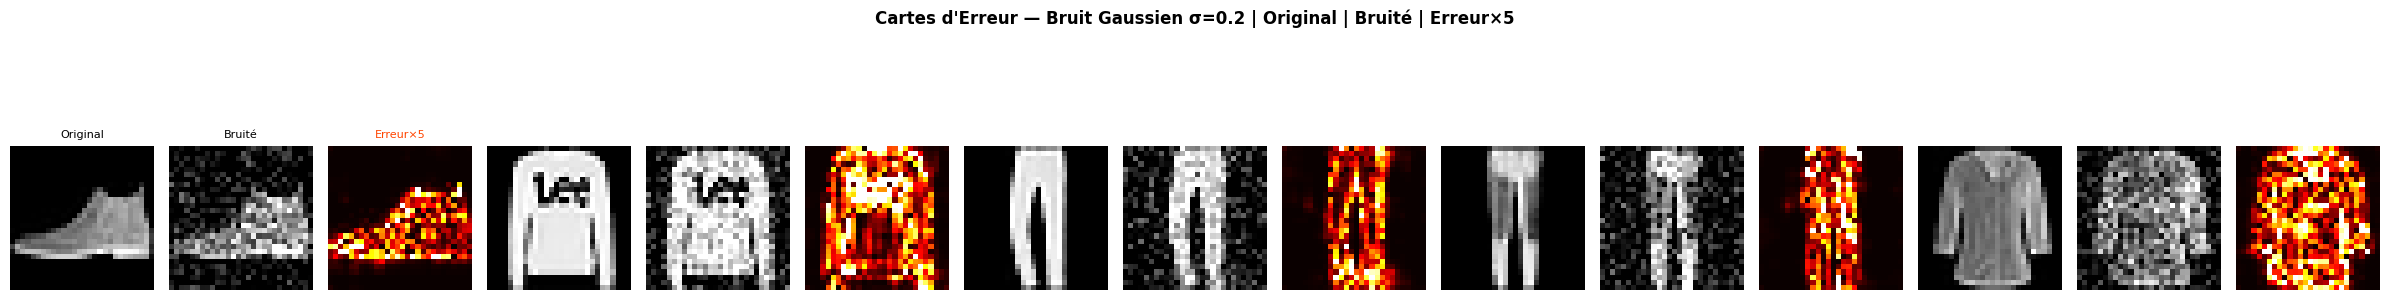

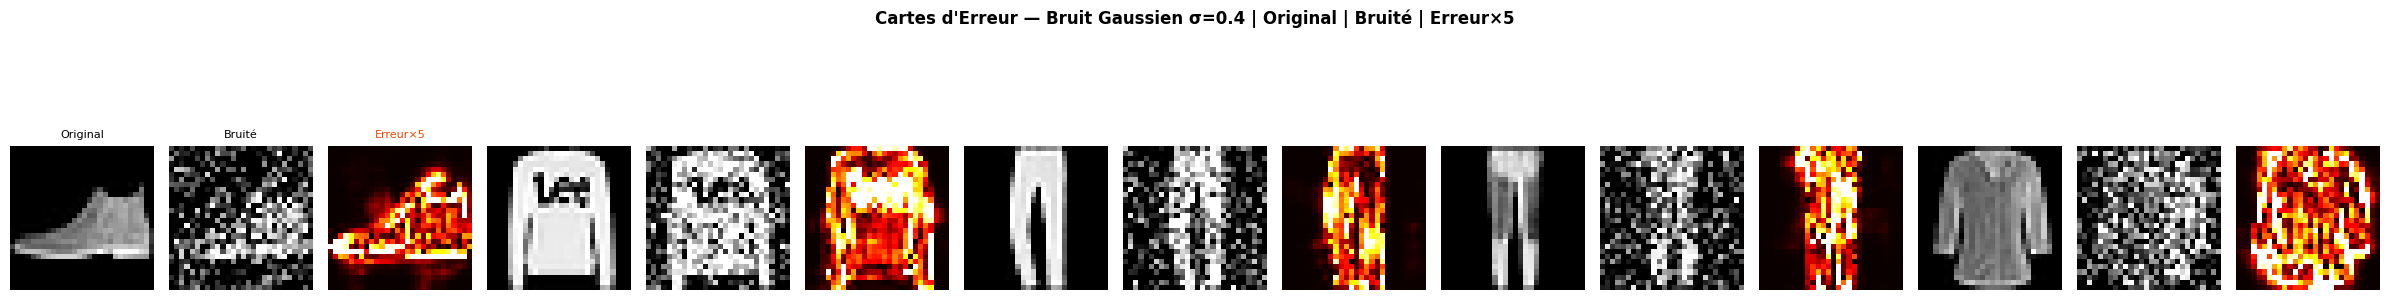

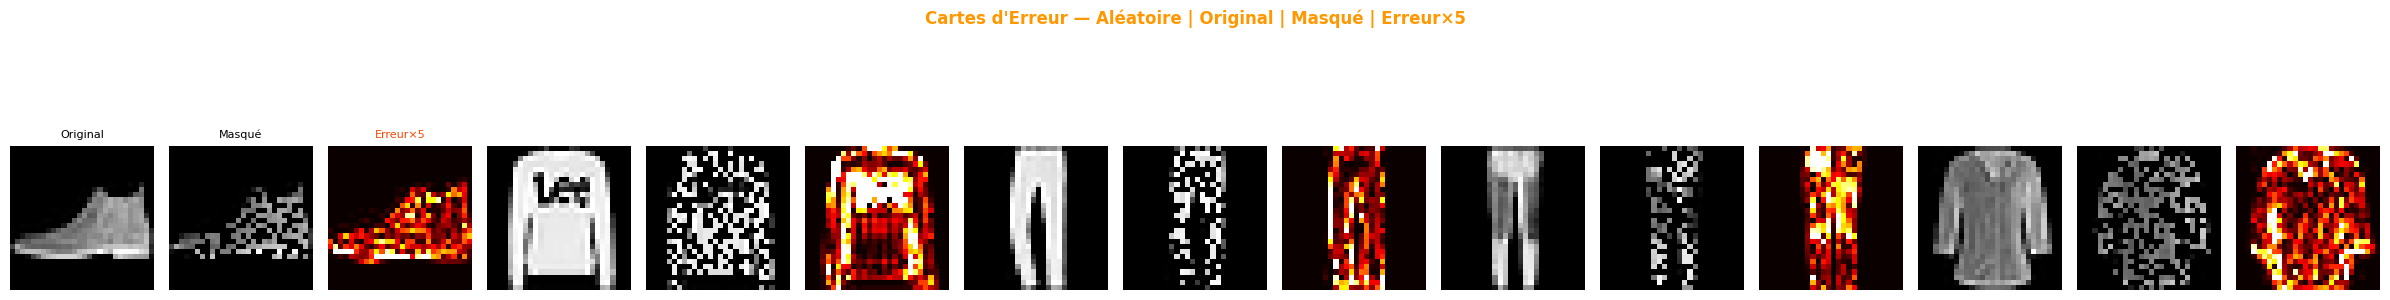

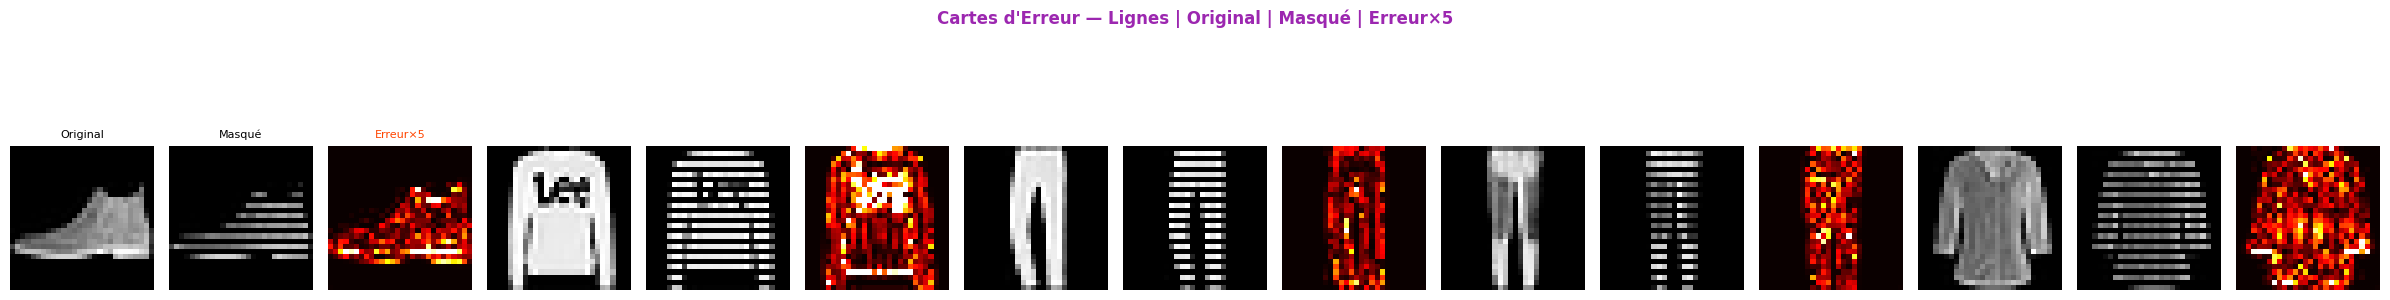

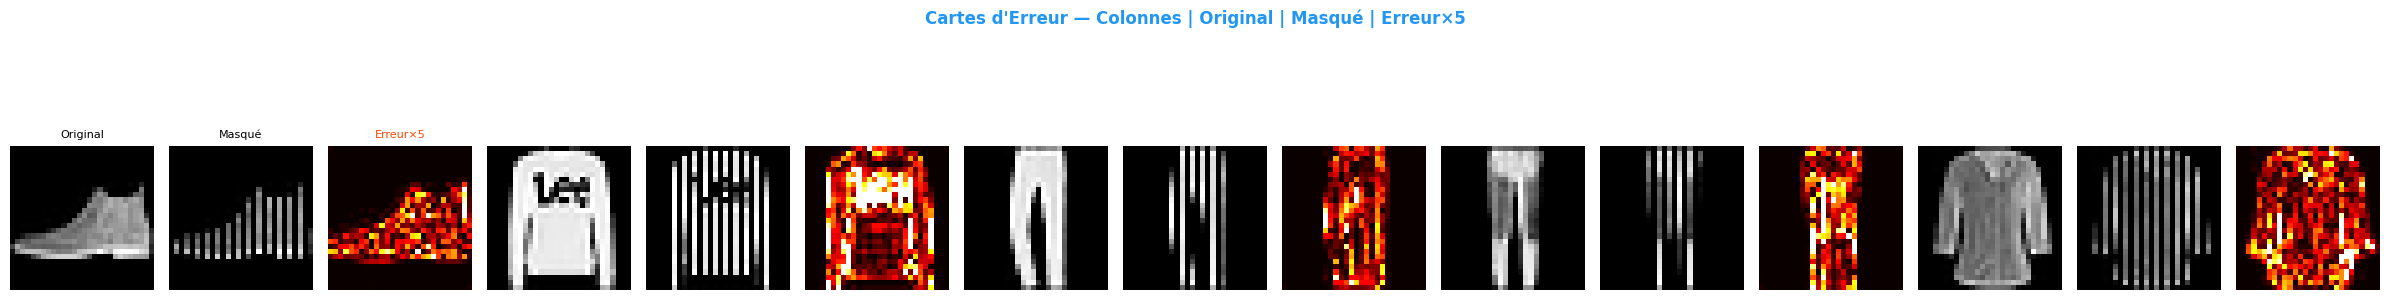

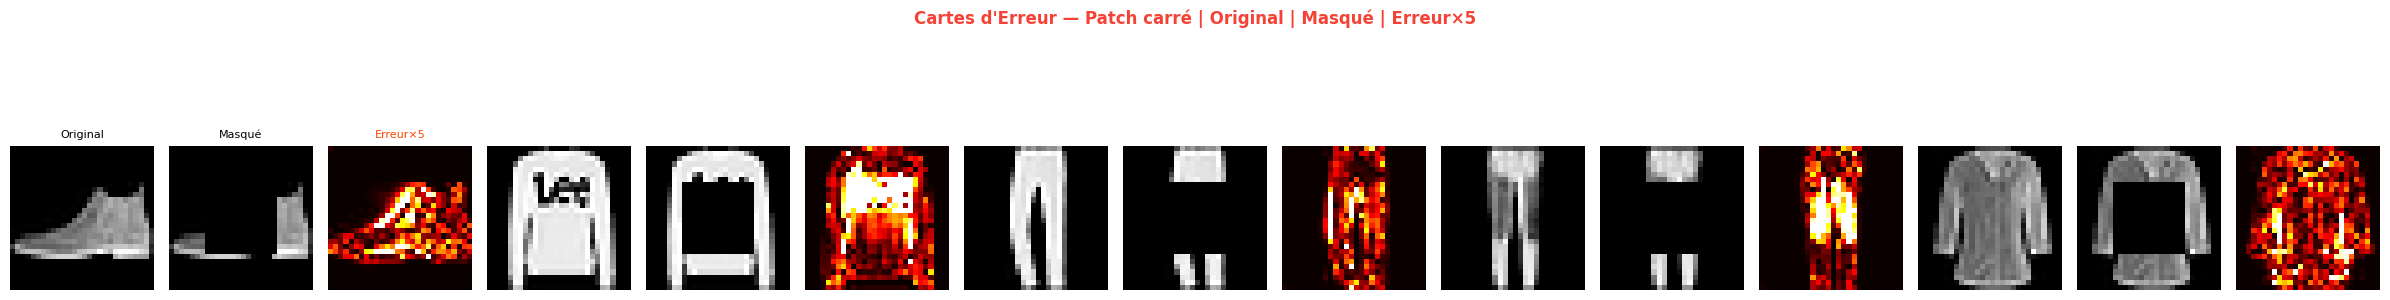

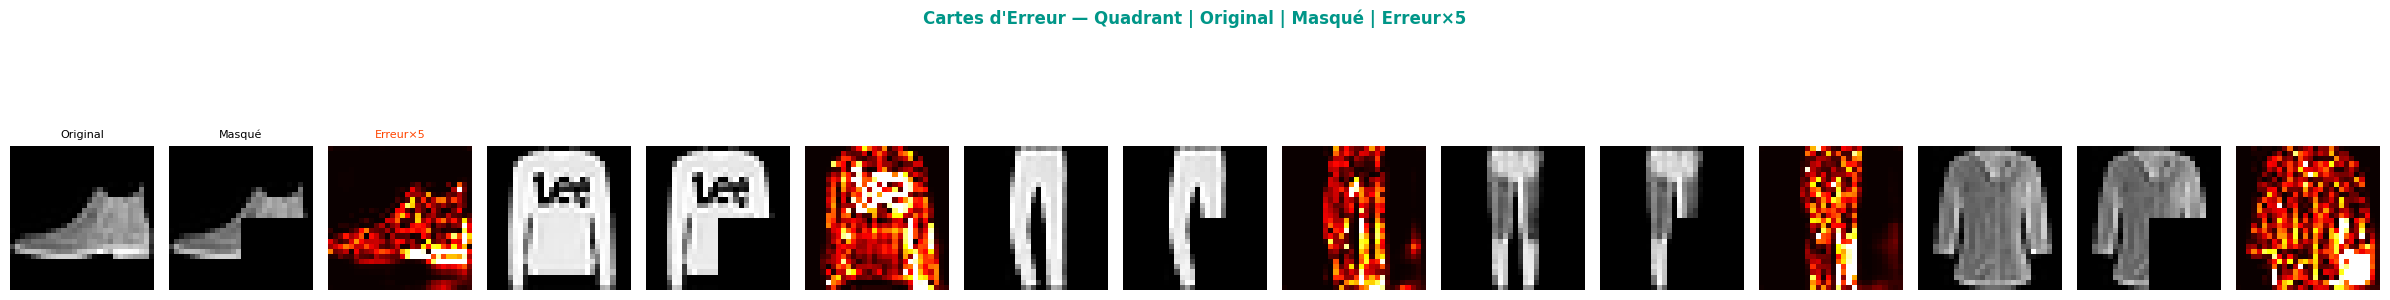

In [40]:
n_show = 5

# ─── Bruit Gaussien : une figure par sigma ────────────────────────────────────
for sigma in SIGMAS:
    fig, axes = plt.subplots(1, n_show * 3, figsize=(24, 4))
    fig.suptitle(f'Cartes d\'Erreur — Bruit Gaussien σ={sigma} | Original | Bruité | Erreur×5',
                 fontsize=12, fontweight='bold')

    masked_arr  = np.array(noisy_data[sigma]['x_test_noisy'])
    decoded_arr = decoded[sigma]['Bruit Gaussien']

    for col in range(n_show):
        orig = np.squeeze(np.array(x_test[col]))
        mskd = np.squeeze(np.array(masked_arr[col]))
        rec  = np.squeeze(decoded_arr[col])
        err  = np.clip(np.abs(orig - rec) * 5, 0, 1)

        base = col * 3
        axes[base+0].imshow(orig, cmap='gray', vmin=0, vmax=1)
        axes[base+1].imshow(mskd, cmap='gray', vmin=0, vmax=1)
        axes[base+2].imshow(err,  cmap='hot',  vmin=0, vmax=1)

        for k in range(3):
            axes[base+k].axis('off')

        if col == 0:
            axes[0].set_title('Original', fontsize=8)
            axes[1].set_title('Bruité',   fontsize=8)
            axes[2].set_title('Erreur×5', fontsize=8, color='orangered')

    plt.tight_layout()
    plt.show()

# ─── Masquages : une figure par masquage (modèle clean) ───────────────────────
for mname in MASKING_FUNCS:
    masked_arr  = masked_test[mname]
    decoded_arr = decoded_clean[mname]

    fig, axes = plt.subplots(1, n_show * 3, figsize=(24, 4))
    fig.suptitle(f'Cartes d\'Erreur — {mname} | Original | Masqué | Erreur×5',
                 fontsize=12, fontweight='bold', color=mask_colors[mname])

    for col in range(n_show):
        orig = np.squeeze(np.array(x_test[col]))
        mskd = np.squeeze(np.array(masked_arr[col]))
        rec  = np.squeeze(decoded_arr[col])
        err  = np.clip(np.abs(orig - rec) * 5, 0, 1)

        base = col * 3
        axes[base+0].imshow(orig, cmap='gray', vmin=0, vmax=1)
        axes[base+1].imshow(mskd, cmap='gray', vmin=0, vmax=1)
        axes[base+2].imshow(err,  cmap='hot',  vmin=0, vmax=1)

        for k in range(3):
            axes[base+k].axis('off')

        if col == 0:
            axes[0].set_title('Original', fontsize=8)
            axes[1].set_title('Masqué',   fontsize=8)
            axes[2].set_title('Erreur×5', fontsize=8, color='orangered')

    plt.tight_layout()
    plt.show()

### 9.1 — Distribution des Erreurs par Masquage et Sigma

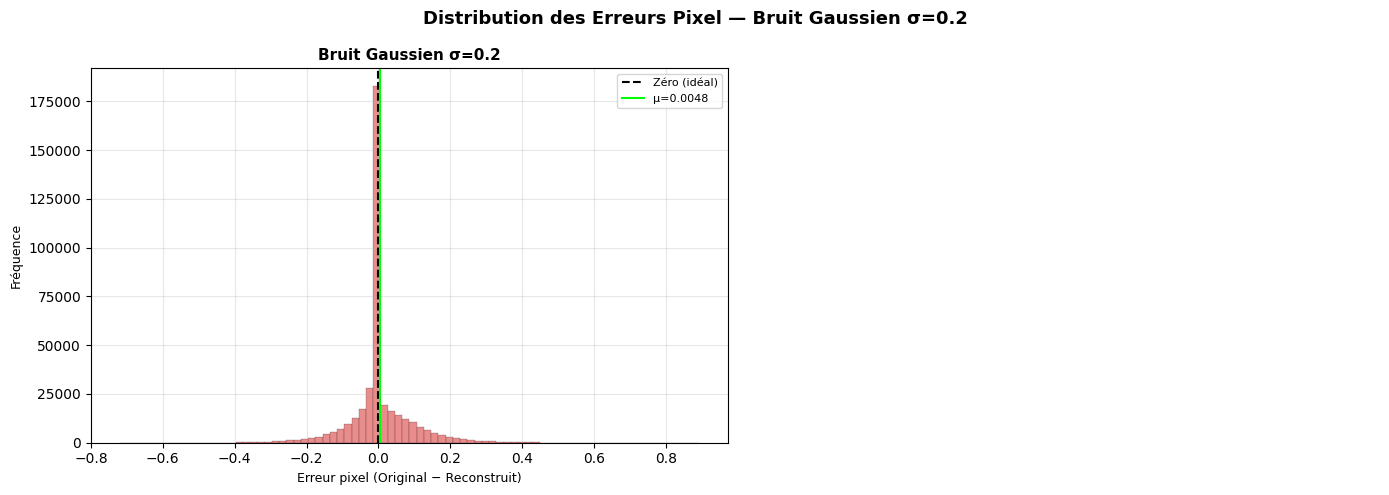

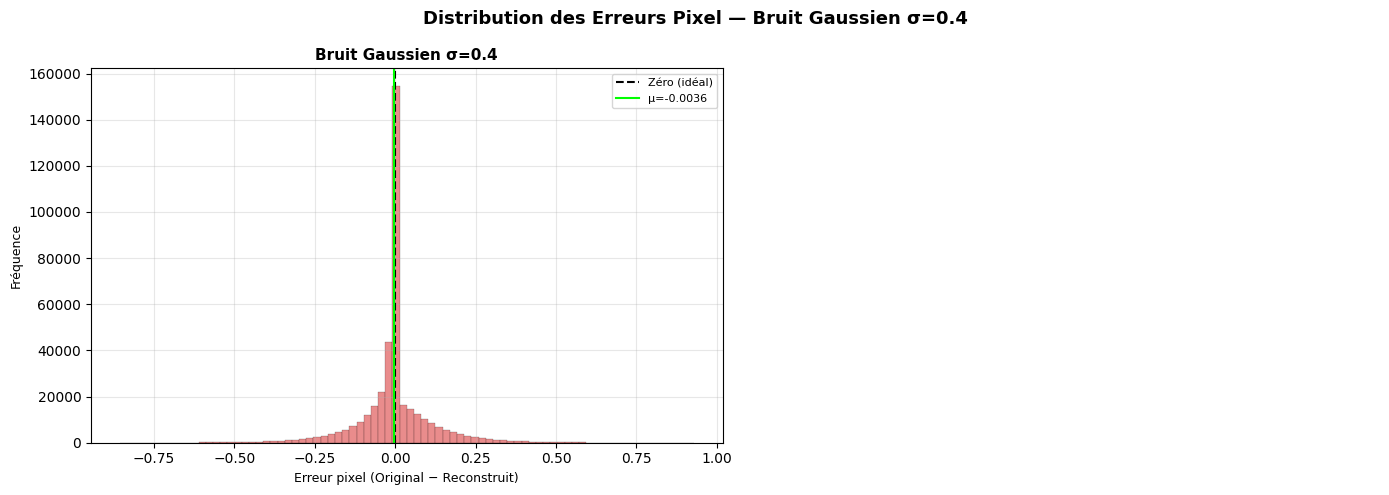

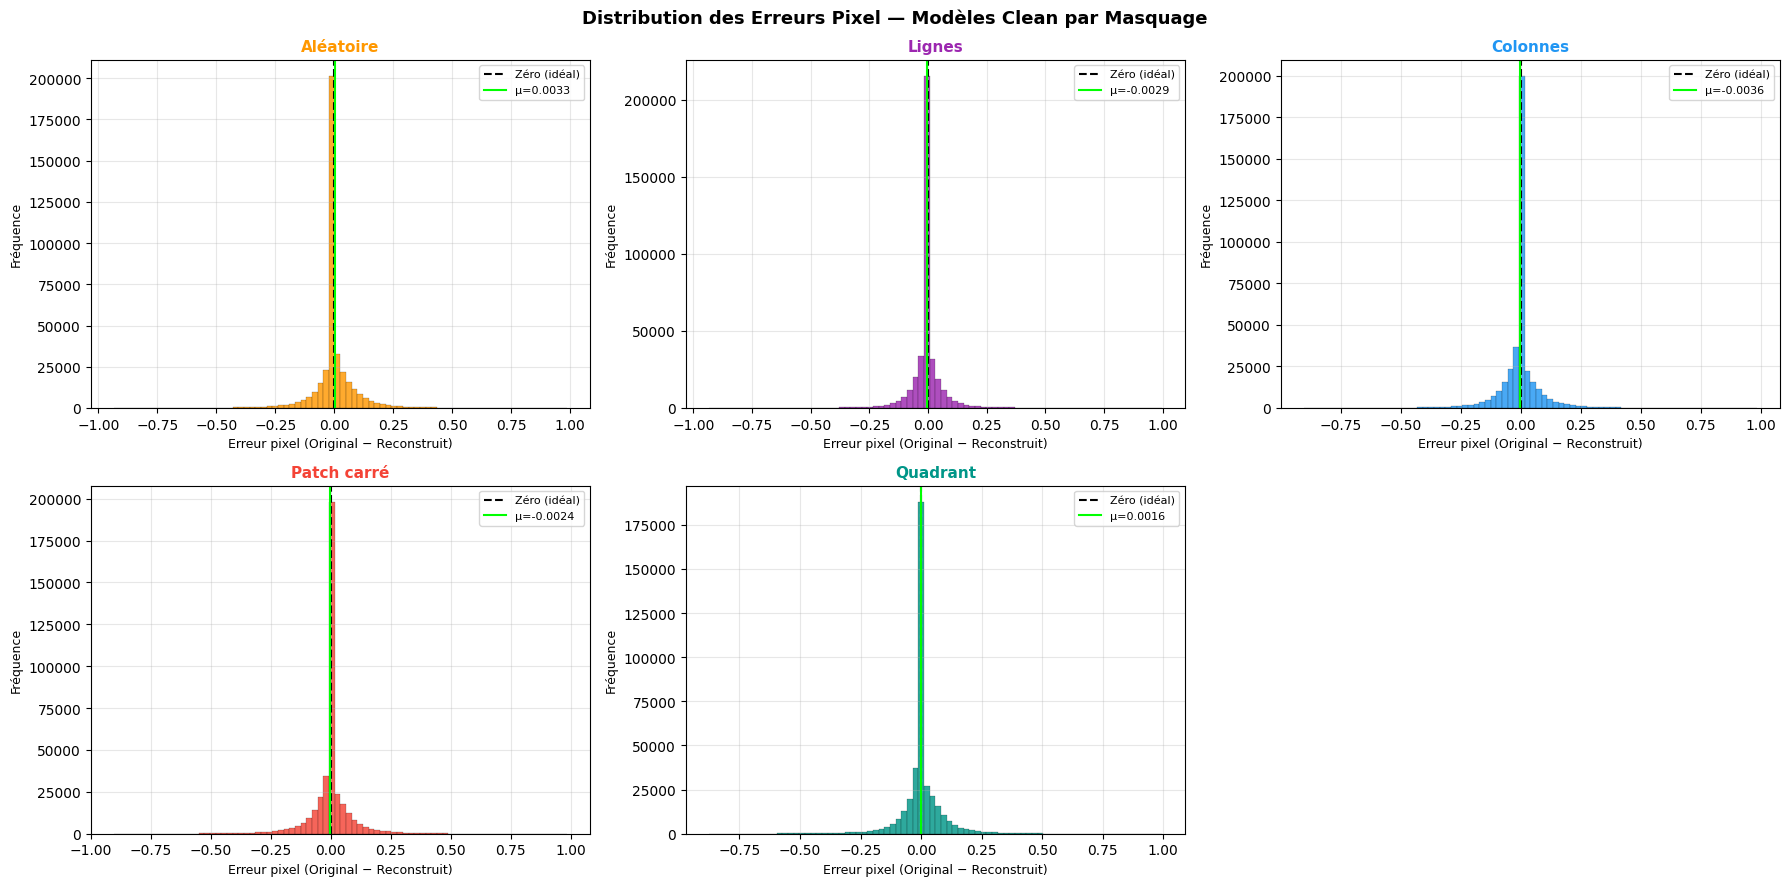

In [41]:
mask_colors = {
    'Aléatoire':   '#FF9800',
    'Lignes':      '#9C27B0',
    'Colonnes':    '#2196F3',
    'Patch carré': '#F44336',
    'Quadrant':    '#009688',
}

n_sample = 500

# ─── Bruit Gaussien : une figure par sigma ────────────────────────────────────
for sigma in SIGMAS:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Distribution des Erreurs Pixel — Bruit Gaussien σ={sigma}',
                 fontsize=13, fontweight='bold')

    for ax, (label, decoded_arr) in zip(axes, [
        (f'Bruité σ={sigma}',  decoded[sigma]['Bruit Gaussien']),
    ]):
        errs = []
        for i in range(min(n_sample, len(x_test))):
            orig = np.squeeze(np.array(x_test[i]))
            rec  = np.squeeze(decoded_arr[i])
            errs.extend((orig - rec).flatten())

        axes[0].hist(errs, bins=80, color='#E57373', alpha=0.82, edgecolor='black', linewidth=0.15)
        axes[0].axvline(0,             color='black', linestyle='--', lw=1.5, label='Zéro (idéal)')
        axes[0].axvline(np.mean(errs), color='lime',  linestyle='-',  lw=1.5,
                        label=f'μ={np.mean(errs):.4f}')
        axes[0].set_title(f'Bruit Gaussien σ={sigma}', fontsize=11, fontweight='bold')
        axes[0].set_xlabel('Erreur pixel (Original − Reconstruit)', fontsize=9)
        axes[0].set_ylabel('Fréquence', fontsize=9)
        axes[0].legend(fontsize=8)
        axes[0].grid(alpha=0.3)
        break

    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

# ─── Masquages : une figure groupée (modèles clean) ───────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle('Distribution des Erreurs Pixel — Modèles Clean par Masquage',
             fontsize=13, fontweight='bold')
axes_flat = axes.flatten()

for idx, mname in enumerate(MASKING_FUNCS):
    color       = mask_colors[mname]
    decoded_arr = decoded_clean[mname]

    errs = []
    for i in range(min(n_sample, len(x_test))):
        orig = np.squeeze(np.array(x_test[i]))
        rec  = np.squeeze(decoded_arr[i])
        errs.extend((orig - rec).flatten())

    ax = axes_flat[idx]
    ax.hist(errs, bins=80, color=color, alpha=0.82, edgecolor='black', linewidth=0.15)
    ax.axvline(0,             color='black', linestyle='--', lw=1.5, label='Zéro (idéal)')
    ax.axvline(np.mean(errs), color='lime',  linestyle='-',  lw=1.5,
               label=f'μ={np.mean(errs):.4f}')
    ax.set_title(mname, fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel('Erreur pixel (Original − Reconstruit)', fontsize=9)
    ax.set_ylabel('Fréquence', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# Cacher le subplot vide (5 masquages → 6e case vide)
axes_flat[5].axis('off')
plt.tight_layout()
plt.show()

---
## 10. Synthèse Finale & Conclusion

### Bilan comparatif des méthodes de masquage

| Méthode | Modèle utilisé | Pixels masqués | Difficulté | Remarque |
|---------|---------------|----------------|------------|----------|
| Bruit Gaussien σ=0.2 | Gaussien σ=0.2 | ~50% (dispersé) | ⭐⭐ | Entraîné directement sur ce bruit |
| Bruit Gaussien σ=0.4 | Gaussien σ=0.4 | ~50% (dispersé) | ⭐⭐⭐ | Bruit plus intense, reconstruction plus difficile |
| Aléatoire | Clean (dédié) | 50% | ⭐⭐ | Contexte local suffisant pour interpolation |
| Lignes | Clean (dédié) | 50% | ⭐⭐⭐ | Interpolation verticale naturelle par convolution |
| Colonnes | Clean (dédié) | 50% | ⭐⭐⭐ | Interpolation horizontale naturelle par convolution |
| Patch carré | Clean (dédié) | 25% | ⭐⭐⭐⭐ | Perte d'info centrale critique — inpainting difficile |
| Quadrant | Clean (dédié) | 25% | ⭐⭐⭐⭐⭐ | Extrapolation depuis 3 quadrants — cas le plus dur |

### Architecture des modèles entraînés

| Modèle | Entrée entraînement | Cible | Usage |
|--------|--------------------|----|-------|
| `models[0.2]` | `x_train + bruit σ=0.2` | `x_train` | Reconstruction bruit gaussien σ=0.2 |
| `models[0.4]` | `x_train + bruit σ=0.4` | `x_train` | Reconstruction bruit gaussien σ=0.4 |
| `models_clean['Aléatoire']` | `masked_train['Aléatoire']` | `x_train` | Reconstruction masquage aléatoire |
| `models_clean['Lignes']` | `masked_train['Lignes']` | `x_train` | Reconstruction masquage lignes |
| `models_clean['Colonnes']` | `masked_train['Colonnes']` | `x_train` | Reconstruction masquage colonnes |
| `models_clean['Patch carré']` | `masked_train['Patch carré']` | `x_train` | Reconstruction masquage patch |
| `models_clean['Quadrant']` | `masked_train['Quadrant']` | `x_train` | Reconstruction masquage quadrant |

> **7 modèles indépendants** entraînés — chacun spécialisé sur un type de corruption.

### Impact du sigma d'entraînement (Bruit Gaussien)

| Sigma | Points forts | Points faibles |
|-------|-------------|----------------|
| **σ=0.2** | Reconstruction précise sur bruit faible | Moins robuste aux corruptions sévères |
| **σ=0.4** | Plus robuste aux corruptions intenses | Légèrement moins précis sur bruit léger |

### Points forts observés
- Les **modèles clean dédiés** surpassent les modèles gaussiens sur tous les types de masquage structuré
- Le masquage **aléatoire** est bien géré : chaque pixel peut s'appuyer sur ses voisins non masqués
- Le masquage par **lignes/colonnes** bénéficie naturellement de la convolution pour interpoler
- Le masquage **patch/quadrant** reste le plus difficile : le réseau doit extrapoler depuis les bords
- La séparation en **un modèle par masquage** permet d'optimiser chaque type de corruption indépendamment

### Métriques d'évaluation utilisées

| Métrique | Sens | Idéal |
|----------|------|-------|
| **MSE** | Erreur quadratique moyenne pixel | → 0 |
| **MAE** | Erreur absolue moyenne pixel | → 0 |
| **PSNR** | Rapport signal/bruit (dB) | ↑ max |
| **SSIM** | Similarité structurelle | → 1 |
| **Pearson** | Corrélation linéaire | → 1 |

### Pistes d'amélioration
- **Ré-entraîner** avec augmentation de données combinant plusieurs types de masquage simultanément
- Utiliser un **Variational Autoencoder (VAE)** pour une représentation latente plus robuste et générative
- Ajouter une **perte perceptuelle** (VGG Loss) pour mieux préserver les textures et structures fines
- Explorer les **Masked Autoencoders (MAE)** — architecture transformeur spécialisée pour ce type de tâche
- Tester un **entraînement mixte** : combiner bruit gaussien + masquages dans un seul modèle unifié

---
> *Ce notebook présente une étude comparative exhaustive :*
> - **2 modèles gaussiens** (`σ=0.2` et `σ=0.4`) évalués sur le débruitage
> - **5 modèles clean dédiés** (`models_clean`) évalués sur la reconstruction par masquage
> - **7 conditions** évaluées sur `N_EVAL` images avec **5 métriques** : MSE, SSIM, PSNR, MAE, Pearson
> - Visualisations : reconstructions, cartes d'erreur pixel-à-pixel, distributions d'erreurs, heatmaps, radar charts
>
> *Résultat clé : un auto-encodeur convolutif spécialisé par type de corruption surpasse significativement un modèle généraliste — illustrant l'importance de l'adéquation entre données d'entraînement et type de corruption à reconstruire.*